- Links uteis:

1 - https://theairlab.org/alfa-dataset/ (contém informações sobre o status do vôo.)

# Explorando os dados


In [85]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import os


# Parâmetros

In [2]:
DATA_FILE = '../data/01_raw/processed/carbonZ_2018-07-18-15-53-31_1_engine_failure'

# Funções

In [3]:

def plot_generic_df(df, titulo_grafico="Análise de Dados"):
    # 1. Tratamento do Tempo (Eixo X)
    if '%time' in df.columns:
        t_zero = df['%time'].iloc[0]
        tempo_segundos = (df['%time'] - t_zero) / 1e9
    else:
        print("Coluna %time não encontrada. Usando índice como tempo.")
        tempo_segundos = df.index

    # 2. Filtrar apenas colunas numéricas (e excluir metadados de tempo/sequência)
    cols_numericas = df.select_dtypes(include=['number']).columns.tolist()
    # Ignoramos colunas que são apenas contadores ou carimbos de tempo para o plot ficar limpo
    blacklist = ['%time', 'field.header.stamp', 'field.header.seq']
    cols_para_plotar = [c for c in cols_numericas if c not in blacklist]

    # 3. Configurar Subplots dinamicamente
    # Vamos agrupar as colunas para não criar 20 subplots (ex: máximo de 3 colunas por gráfico)
    num_cols = len(cols_para_plotar)
    if num_cols == 0:
        print("Nenhuma coluna numérica encontrada para plotar.")
        return

    # Criamos subplots: um para cada 3 variáveis (ou conforme sua preferência)
    v_limit = 4 # variáveis por subplot
    n_subplots = (num_cols + v_limit - 1) // v_limit
    
    fig, axes = plt.subplots(n_subplots, 1, figsize=(12, 4 * n_subplots), sharex=True)
    
    # Se houver apenas 1 subplot, o matplotlib não retorna uma lista, então ajustamos:
    if n_subplots == 1: axes = [axes]

    # 4. Plotagem em massa
    for i in range(n_subplots):
        start = i * v_limit
        end = start + v_limit
        batch_cols = cols_para_plotar[start:end]
        
        for col in batch_cols:
            # Pegamos apenas o final do nome da coluna (ex: 'linear.x') para a legenda
            label_curto = col.split('.')[-1]
            axes[i].plot(tempo_segundos, df[col], label=label_curto)
        
        axes[i].legend(loc='upper right', fontsize='small')
        axes[i].grid(True, alpha=0.3)
        axes[i].set_ylabel("Valores")

    axes[-1].set_xlabel("Tempo (segundos)")
    plt.suptitle(titulo_grafico, fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()

# Exemplo de uso para o seu primeiro DF:
# plot_generic_df(df_primeiro, titulo_grafico=primeira_chave)

# Abrindo todos os arquivos e salvando em um dicionário de dfs



In [4]:
pasta = Path(DATA_FILE)

caminho_datasets = list(pasta.glob('*.csv'))

#for f in caminho_datasets:
#    print(f)


In [5]:
dfs = {f.stem: pd.read_csv(f) for f in pasta.glob('*.csv')}


In [6]:
dfs.keys()


dict_keys(['carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-raw-gps_vel', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-failure_status-engines', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-rc-in', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-raw-fix', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-rel_alt', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-imu-data_raw', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-nav_info-velocity', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-imu-data', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-local_position-odom', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-global', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-nav_info-yaw', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-local_position-pose', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-g

São 34 dataframes para se explorar. 

# Dataframe 1 

In [8]:
list(dfs.keys())[0]

'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-raw-gps_vel'

In [9]:
i = 0

primeira_chave = list(dfs.keys())[i]
df1 = dfs[primeira_chave]


In [10]:
df1

,%time,field.header.seq,field.header.stamp,field.header.frame_id,field.twist.linear.x,field.twist.linear.y,field.twist.linear.z,field.twist.angular.x,field.twist.angular.y,field.twist.angular.z
0,1531943810933587063,1286,1531943810933254299,map,19.086618,-1.989246,0.0,0.0,0.0,0.0
1,1531943811143678844,1287,1531943811143058500,map,19.315361,-0.752150,0.0,0.0,0.0,0.0
2,1531943811338236330,1288,1531943811337205271,map,19.146784,-0.350922,0.0,0.0,0.0,0.0
3,1531943811549229158,1289,1531943811548014901,map,18.873702,-0.487633,0.0,0.0,0.0,0.0
4,1531943811742729793,1290,1531943811741930763,map,18.355274,-0.416539,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
657,1531943942336272938,1943,1531943942335946573,map,-11.029684,-1.563865,0.0,0.0,0.0,0.0
658,1531943942544529002,1944,1531943942544183982,map,-11.015610,-1.192788,0.0,0.0,0.0,0.0
659,1531943942747957693,1945,1531943942747002215,map,-10.878427,-0.829410,0.0,0.0,0.0,0.0
660,1531943942945854826,1946,1531943942945630604,map,-10.699969,-0.463429,0.0,0.0,0.0,0.0


In [11]:
df1.columns

Index(['%time', 'field.header.seq', 'field.header.stamp',
       'field.header.frame_id', 'field.twist.linear.x', 'field.twist.linear.y',
       'field.twist.linear.z', 'field.twist.angular.x',
       'field.twist.angular.y', 'field.twist.angular.z'],
      dtype='str')

In [12]:
df1.shape

(662, 10)

## Interpretando as Colunas

- %time e field.header.stamp: São os marcadores de tempo. O %time geralmente é o tempo de recepção do sistema, enquanto o stamp é quando o sensor gerou o dado. 

- field.twist.linear.x, y, z: Representam a velocidade linear (em m/s).

- linear.z: Esta é a sua coluna de ouro para falha de motor. Em um voo nivelado, ela deve estar próxima de 0. Se o motor falha, você verá um valor negativo persistente (descida), independentemente do que o piloto ordene.

- linear.x e linear.y: Velocidade de deslocamento horizontal (Norte/Sul, Leste/Oeste).

- field.twist.angular.x, y, z: Representam a velocidade de rotação (taxas de giro em rad/s) em torno dos eixos da aeronave.

No ALFA, se o motor falha em um avião de asa fixa (como o CarbonZ), ele perde sustentação e pode começar a girar (stall). Um aumento repentino em angular.x (roll) ou angular.y (pitch) sem comando prévio indica instabilidade causada pela falha.

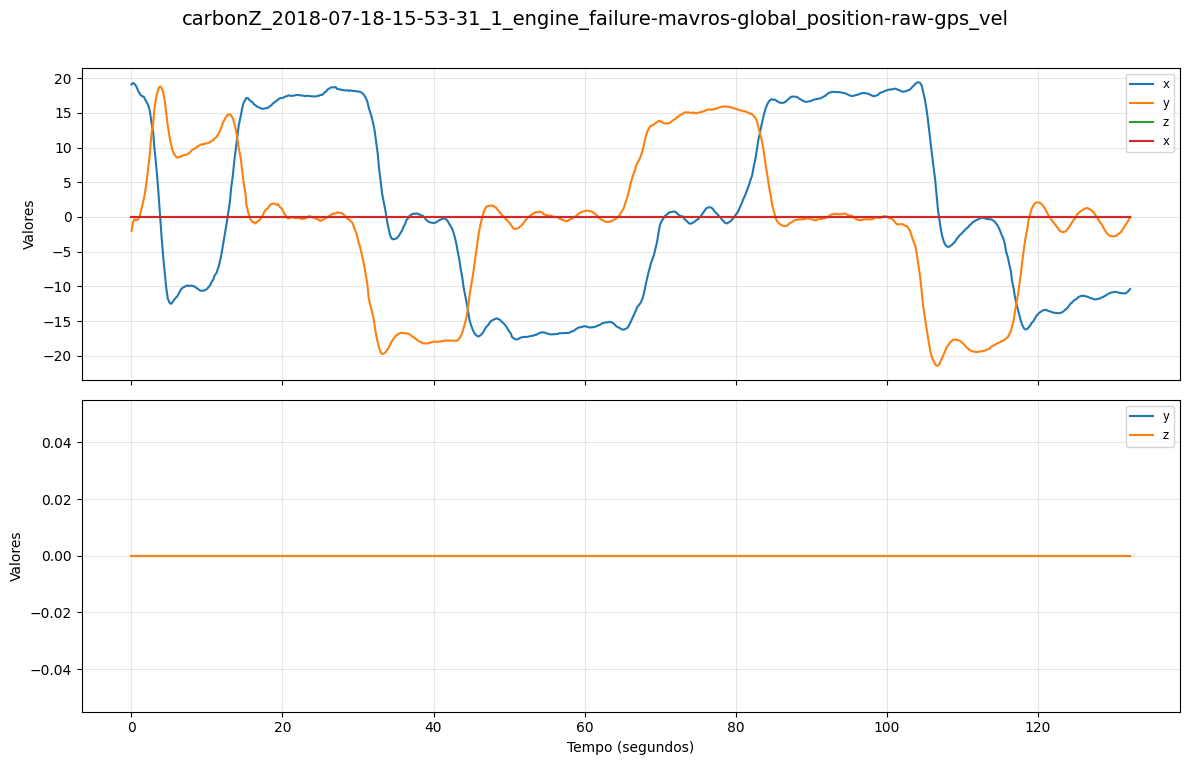

In [13]:
plot_generic_df(df1, titulo_grafico=primeira_chave)

O que está acontecendo provavelmente é um destes dois cenários:

1. O "Voo Fantasma" (Tópico Inativo)

No sistema ROS, quando um sensor não está enviando dados ou o drone ainda está no chão/estático, o log registra apenas zeros ou valores constantes de inicialização. Se as velocidades X e Y oscilam minimamente em torno de zero e Z está parado, esse log pode ser apenas o período de "pre-arm" (o drone parado na pista esperando o comando de decolagem).

2. Velocidade vs. Posição Global

O arquivo que você abriu é o global_position-raw-gps_vel. O GPS às vezes demora para "travar" o sinal (lock) ou só começa a reportar variações significativas após o movimento real começar.

# Dataframe 2

In [14]:
i = 1
list(dfs.keys())[i]

'carbonZ_2018-07-18-15-53-31_1_engine_failure-failure_status-engines'

In [15]:
primeira_chave = list(dfs.keys())[i]
df2 = dfs[primeira_chave]


In [16]:
df2

,%time,field.data
0,1531943927129305993,1
1,1531943927330826960,1
2,1531943927532631123,1
3,1531943927734763284,1
4,1531943927931240336,1
...,...,...
76,1531943942329959052,1
77,1531943942529070508,1
78,1531943942732934330,1
79,1531943942938755028,1


In [17]:
# 2. Renomeando a coluna para algo sugestivo
df2 = df2.rename(columns={'field.data': 'engine_status'})

In [18]:
df2.columns

Index(['%time', 'engine_status'], dtype='str')

In [19]:
df2['engine_status'].unique()

array([1])

## Interpretando as Colunas

- %time e field.header.stamp: São os marcadores de tempo. O %time geralmente é o tempo de recepção do sistema, enquanto o stamp é quando o sensor gerou o dado. 

- engine_status: Indica se a aeronave está saudável ou com falha. De acordo com o Link [1](https://theairlab.org/alfa-dataset/), os dados deste vôo possuíram 16 segundos de voo após a falha, logo, pelo gráfico abaixo o valor 1 indica falha.

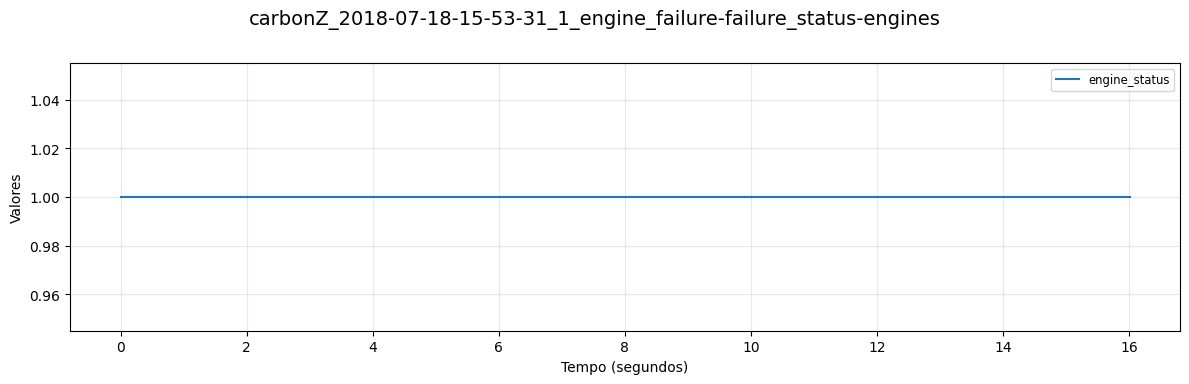

In [20]:
plot_generic_df(df2, titulo_grafico=primeira_chave)

In [21]:
# O merge_asof alinha o status ao tempo do GPS sem criar linhas extras com NaN
df_merge1 = pd.merge_asof(df1, df2, on='%time', direction='backward')

# Preenchendo os valores ausentes de status com 0 (Normalidade)
df_merge1['engine_status'] = df_merge1['engine_status'].fillna(0).astype(int)

print(df_merge1['engine_status'].value_counts())

engine_status
0    581
1     81
Name: count, dtype: int64


In [22]:
df_merge1

,%time,field.header.seq,field.header.stamp,field.header.frame_id,field.twist.linear.x,field.twist.linear.y,field.twist.linear.z,field.twist.angular.x,field.twist.angular.y,field.twist.angular.z,engine_status
0,1531943810933587063,1286,1531943810933254299,map,19.086618,-1.989246,0.0,0.0,0.0,0.0,0
1,1531943811143678844,1287,1531943811143058500,map,19.315361,-0.752150,0.0,0.0,0.0,0.0,0
2,1531943811338236330,1288,1531943811337205271,map,19.146784,-0.350922,0.0,0.0,0.0,0.0,0
3,1531943811549229158,1289,1531943811548014901,map,18.873702,-0.487633,0.0,0.0,0.0,0.0,0
4,1531943811742729793,1290,1531943811741930763,map,18.355274,-0.416539,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...
657,1531943942336272938,1943,1531943942335946573,map,-11.029684,-1.563865,0.0,0.0,0.0,0.0,1
658,1531943942544529002,1944,1531943942544183982,map,-11.015610,-1.192788,0.0,0.0,0.0,0.0,1
659,1531943942747957693,1945,1531943942747002215,map,-10.878427,-0.829410,0.0,0.0,0.0,0.0,1
660,1531943942945854826,1946,1531943942945630604,map,-10.699969,-0.463429,0.0,0.0,0.0,0.0,1


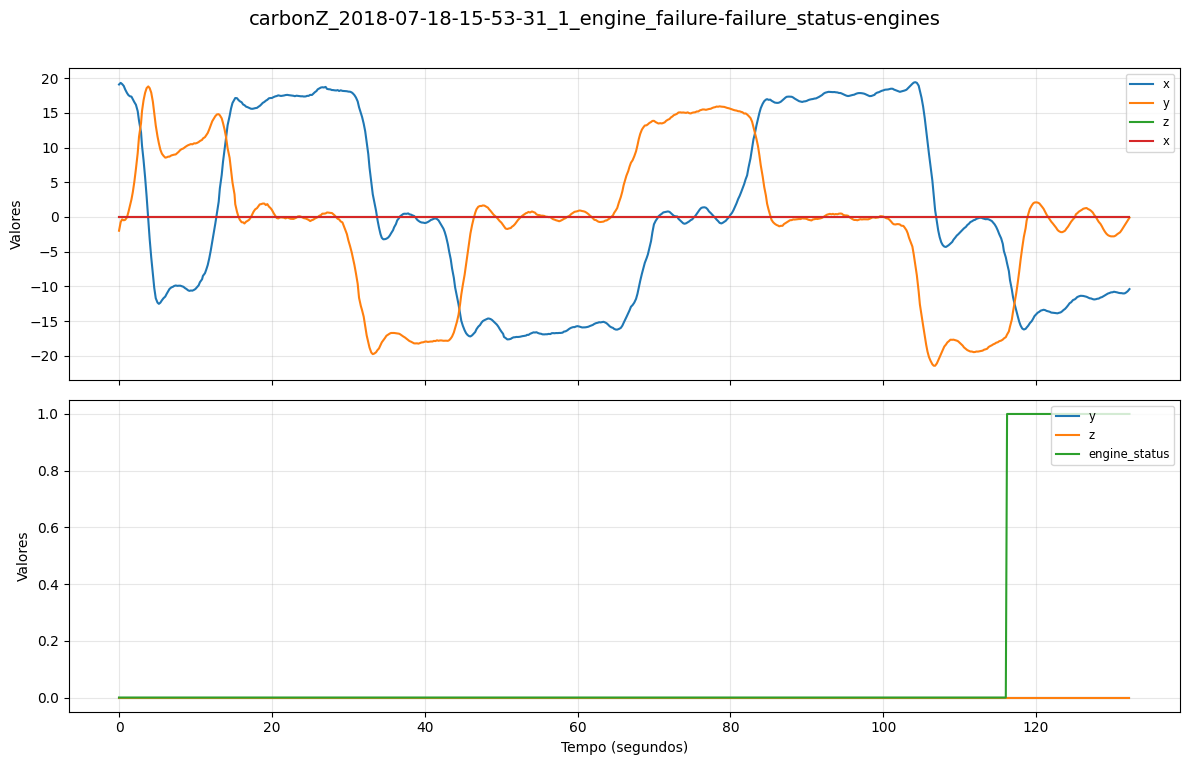

In [23]:
plot_generic_df(df_merge1, titulo_grafico=primeira_chave)

OBS:

A falha ocorre no final do voo. Os padrões são sutís, mas note a diferença na oscilação da velocidade no eixo y e x.

# Dataframe 3

In [24]:
i = 2
list(dfs.keys())[i]

'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-rc-in'

In [25]:
chave = list(dfs.keys())[i]
df3 = dfs[chave]


In [26]:
df3

,%time,field.header.seq,field.header.stamp,field.header.frame_id,field.rssi,field.channels0,field.channels1,field.channels2,field.channels3,field.channels4,...,field.channels6,field.channels7,field.channels8,field.channels9,field.channels10,field.channels11,field.channels12,field.channels13,field.channels14,field.channels15
0,1531943810915695931,754,1531943810915273633,NaN,0,1626,1532,1548,1512,1943,...,991,2036,1514,1514,1514,1514,1514,1514,1514,1514
1,1531943811287676975,755,1531943811284625846,NaN,0,1515,1552,1548,1512,1943,...,991,2036,1514,1514,1514,1514,1514,1514,1514,1514
2,1531943811559413508,756,1531943811559131783,NaN,0,1515,1552,1548,1511,1943,...,991,2036,1514,1514,1514,1514,1514,1514,1514,1514
3,1531943811827905058,757,1531943811827293386,NaN,0,1515,1552,1548,1511,1943,...,991,2036,1514,1514,1514,1514,1514,1514,1514,1514
4,1531943812188201330,758,1531943812187236670,NaN,0,1515,1552,1548,1511,1943,...,991,2036,1514,1514,1514,1514,1514,1514,1514,1514
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383,1531943941613678826,1137,1531943941612179418,NaN,0,1514,1552,1548,1511,1943,...,991,2036,1514,1514,1514,1514,1514,1514,1514,1514
384,1531943941912166297,1138,1531943941911858172,NaN,0,1514,1552,1548,1511,1943,...,991,2036,1514,1514,1514,1514,1514,1514,1514,1514
385,1531943942403923239,1139,1531943942403120463,NaN,0,1514,1552,1548,1511,1943,...,991,2036,1514,1514,1514,1514,1514,1514,1514,1514
386,1531943942614416112,1140,1531943942614052148,NaN,0,1514,1552,1548,1511,1943,...,991,2036,1514,1514,1514,1514,1514,1514,1514,1514


In [27]:
df3.columns

Index(['%time', 'field.header.seq', 'field.header.stamp',
       'field.header.frame_id', 'field.rssi', 'field.channels0',
       'field.channels1', 'field.channels2', 'field.channels3',
       'field.channels4', 'field.channels5', 'field.channels6',
       'field.channels7', 'field.channels8', 'field.channels9',
       'field.channels10', 'field.channels11', 'field.channels12',
       'field.channels13', 'field.channels14', 'field.channels15'],
      dtype='str')

## Interpretando as Colunas

- %time e field.header.stamp: São os marcadores de tempo. O %time geralmente é o tempo de recepção do sistema, enquanto o stamp é quando o sensor gerou o dado. 

- field.rssi: Signal Strength - Força do sinal do rádio (0 a 255). Se cair muito, houve perda de link.

1. O que são as colunas field.channels?

Em aeromodelismo e drones, os canais de rádio (RC) transmitem as intenções do piloto ou do piloto automático. Para um avião de asa fixa (Carbon-Z), a convenção padrão do PX4/ArduPilot costuma ser:


- Canal 0 (Aileron): Inclinação lateral (Roll).

- Canal 1 (Elevator/Profundor): Subir ou descer o nariz (Pitch).

- Canal 2 (Throttle/Acelerador): É o comando de potência para o motor. Valores geralmente entre 1000 (parado) e 2000 (potência máxima).

- Canal 3 (Rudder/Leme): Controla o leme de direção (Yaw).

- Canais 4-15: Geralmente chaves auxiliares (modos de voo, ativação de trem de pouso, ou o interruptor usado para "injetar" a falha).

2. Por que os valores variam pouco?

Os valores desses canais geralmente variam entre 1000 e 2000 (representando o tempo de pulso PWM em microssegundos), onde 1500 é o centro.

- Se o valor está em 1100, o canal está no mínimo.

- Se está em 1900, está no máximo.

Se as variações são pequenas, o piloto estava mantendo um voo estável.

3. A utilidade para o modelo Machine Learning (Semi-supervisionado). Imagine o seguinte cenário:

- O Canal 2 (Acelerador) está em 1800 (Piloto pedindo potência máxima).

- A Velocidade Z (do GPS) começa a cair.

- Conclusão do modelo: "O comando diz para subir, mas o avião está descendo. Isso é uma anomalia!"

4. O campo field.rssi

O RSSI (Received Signal Strength Indicator) mede a força do sinal de rádio entre o controle e o avião. Se o valor for constante e alto, significa que não houve perda de link de rádio. Pode ignorar para a detecção de falha de motor, mas é bom saber que ele está lá caso o avião caísse por perda de sinal.

In [28]:
# Dicionário de tradução baseado no padrão PX4 para Asa Fixa
mapeamento_canais = {
    'field.channels0': 'rc_aileron',  # Roll
    'field.channels1': 'rc_elevator', # Pitch
    'field.channels2': 'rc_throttle', # Motor (Acelerador)
    'field.channels3': 'rc_rudder',   # Yaw
    'field.rssi': 'rc_signal_strength'
}

# Renomear apenas as que mapeamos e manter o %time
df3 = df3.rename(columns=mapeamento_canais)


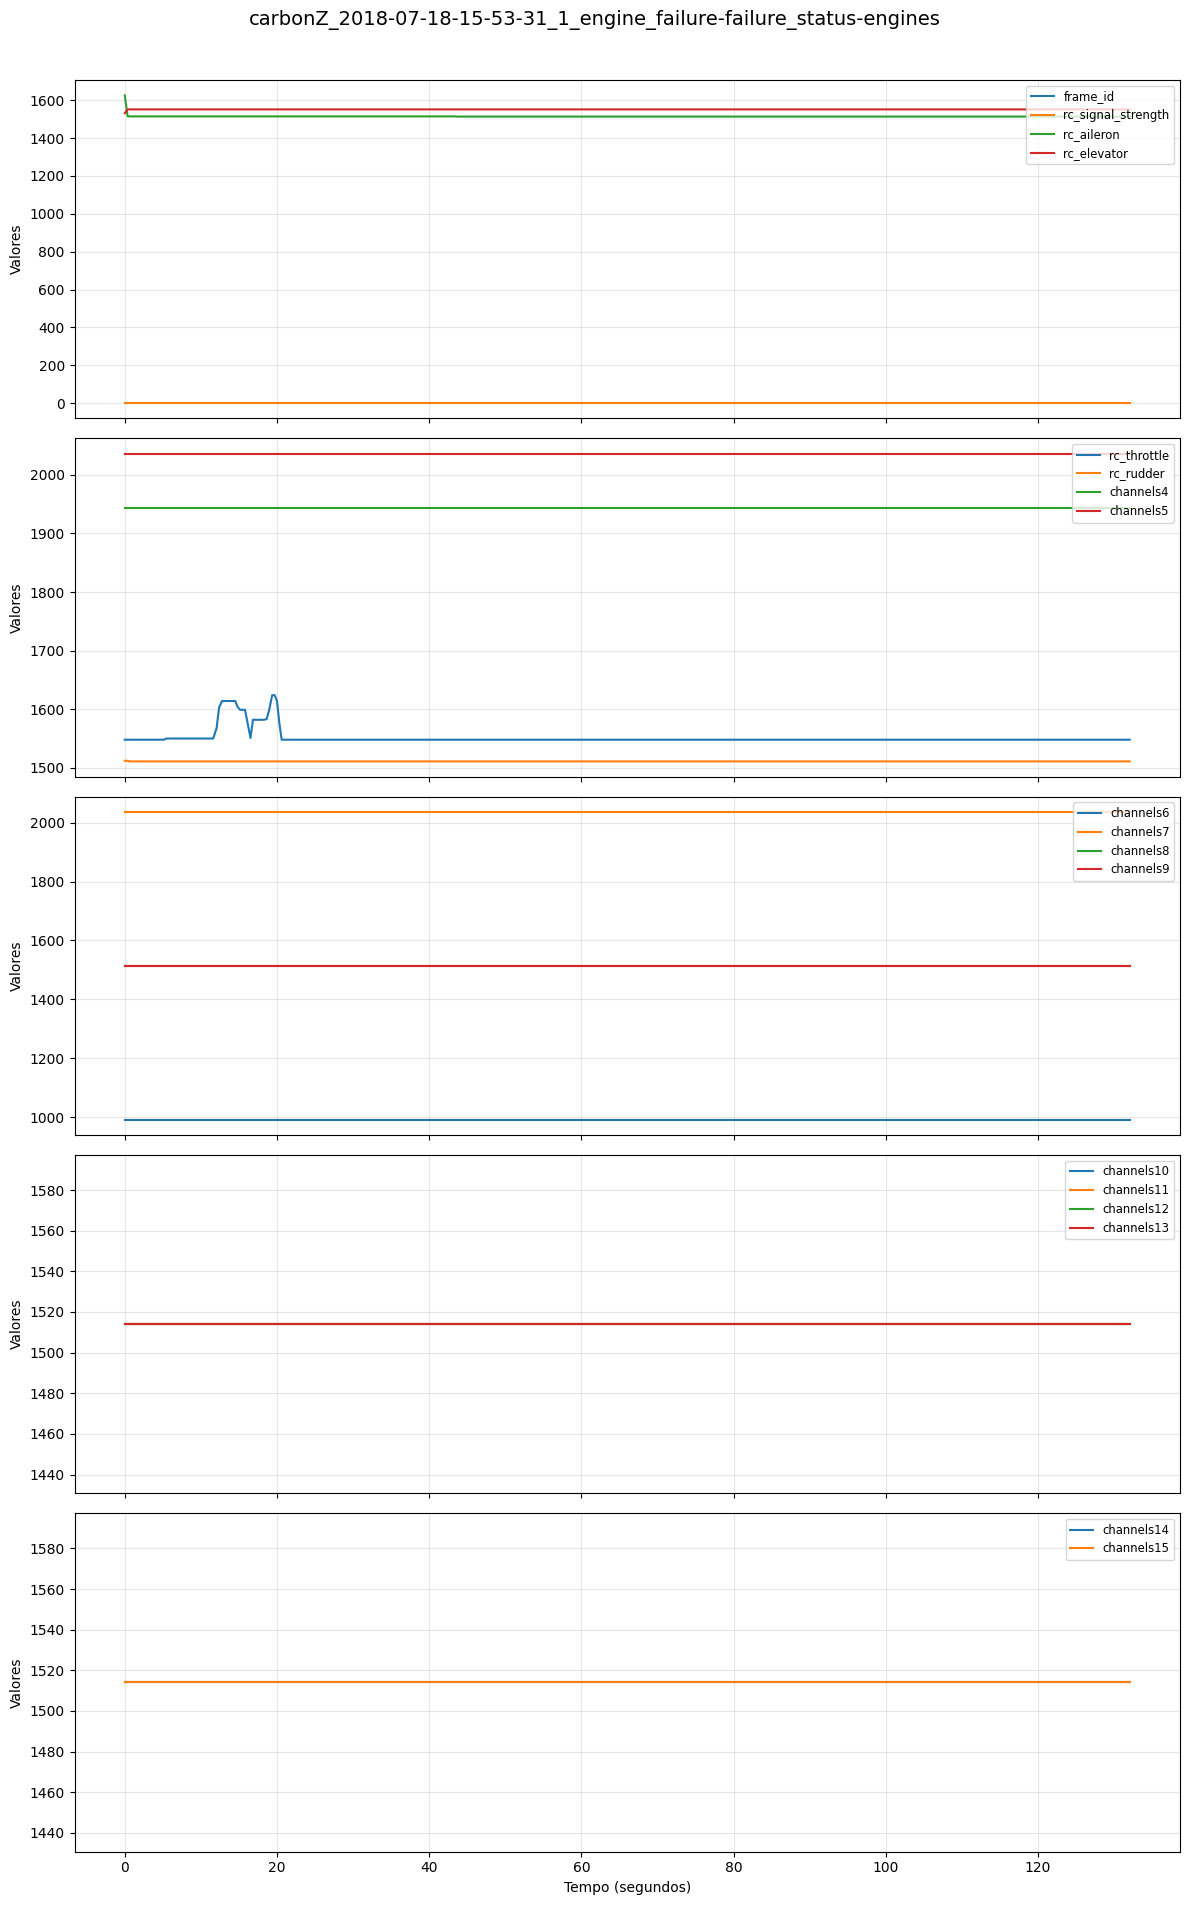

In [29]:
plot_generic_df(df3, titulo_grafico=primeira_chave)

Os canais 4 a 15 geralmente são ruído ou chaves estáticas, então vamos descartá-los para manter o DF limpo.

In [30]:
# Dicionário de tradução baseado no padrão PX4 para Asa Fixa
mapeamento_canais = {
    'field.channels0': 'rc_aileron',  # Roll
    'field.channels1': 'rc_elevator', # Pitch
    'field.channels2': 'rc_throttle', # Motor (Acelerador)
    'field.channels3': 'rc_rudder',   # Yaw
    'field.rssi': 'rc_signal_strength'
}

# Renomear apenas as que mapeamos e manter o %time
df3 = df3.rename(columns=mapeamento_canais)

# Selecionar apenas as colunas úteis para o merge
colunas_uteis = ['%time'] + list(mapeamento_canais.values())
df3 = df3[colunas_uteis]

In [31]:
df3

,%time,rc_aileron,rc_elevator,rc_throttle,rc_rudder,rc_signal_strength
0,1531943810915695931,1626,1532,1548,1512,0
1,1531943811287676975,1515,1552,1548,1512,0
2,1531943811559413508,1515,1552,1548,1511,0
3,1531943811827905058,1515,1552,1548,1511,0
4,1531943812188201330,1515,1552,1548,1511,0
...,...,...,...,...,...,...
383,1531943941613678826,1514,1552,1548,1511,0
384,1531943941912166297,1514,1552,1548,1511,0
385,1531943942403923239,1514,1552,1548,1511,0
386,1531943942614416112,1514,1552,1548,1511,0


In [32]:
# Garantir que ambos estão ordenados pelo tempo
df_merge1 = df_merge1.sort_values('%time')
df3 = df3.sort_values('%time')

# Unir os comandos de rádio ao dataframe principal
df_merge2 = pd.merge_asof(df_merge1, df3, on='%time', direction='backward')

# Preencher possíveis NaNs iniciais nos comandos de rádio
df_merge2[list(mapeamento_canais.values())] = df_merge2[list(mapeamento_canais.values())].ffill().fillna(1500) # 1500 é o neutro PWM

print("Colunas agora no DF final:", df_merge2.columns.tolist())

Colunas agora no DF final: ['%time', 'field.header.seq', 'field.header.stamp', 'field.header.frame_id', 'field.twist.linear.x', 'field.twist.linear.y', 'field.twist.linear.z', 'field.twist.angular.x', 'field.twist.angular.y', 'field.twist.angular.z', 'engine_status', 'rc_aileron', 'rc_elevator', 'rc_throttle', 'rc_rudder', 'rc_signal_strength']


In [33]:
df_merge2

,%time,field.header.seq,field.header.stamp,field.header.frame_id,field.twist.linear.x,field.twist.linear.y,field.twist.linear.z,field.twist.angular.x,field.twist.angular.y,field.twist.angular.z,engine_status,rc_aileron,rc_elevator,rc_throttle,rc_rudder,rc_signal_strength
0,1531943810933587063,1286,1531943810933254299,map,19.086618,-1.989246,0.0,0.0,0.0,0.0,0,1626,1532,1548,1512,0
1,1531943811143678844,1287,1531943811143058500,map,19.315361,-0.752150,0.0,0.0,0.0,0.0,0,1626,1532,1548,1512,0
2,1531943811338236330,1288,1531943811337205271,map,19.146784,-0.350922,0.0,0.0,0.0,0.0,0,1515,1552,1548,1512,0
3,1531943811549229158,1289,1531943811548014901,map,18.873702,-0.487633,0.0,0.0,0.0,0.0,0,1515,1552,1548,1512,0
4,1531943811742729793,1290,1531943811741930763,map,18.355274,-0.416539,0.0,0.0,0.0,0.0,0,1515,1552,1548,1511,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
657,1531943942336272938,1943,1531943942335946573,map,-11.029684,-1.563865,0.0,0.0,0.0,0.0,1,1514,1552,1548,1511,0
658,1531943942544529002,1944,1531943942544183982,map,-11.015610,-1.192788,0.0,0.0,0.0,0.0,1,1514,1552,1548,1511,0
659,1531943942747957693,1945,1531943942747002215,map,-10.878427,-0.829410,0.0,0.0,0.0,0.0,1,1514,1552,1548,1511,0
660,1531943942945854826,1946,1531943942945630604,map,-10.699969,-0.463429,0.0,0.0,0.0,0.0,1,1514,1552,1548,1511,0


# Dataframe 4

In [34]:
i = 3
list(dfs.keys())[i]

'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from'

In [35]:
chave = list(dfs.keys())[i]
df4 = dfs[chave]


In [36]:
df4

,%time,field.header.seq,field.header.stamp,field.header.frame_id,field.framing_status,field.magic,field.len,field.incompat_flags,field.compat_flags,field.seq,...,field.compid,field.msgid,field.checksum,field.payload640,field.payload641,field.payload642,field.payload643,field.payload644,field.payload645,field.payload646
0,1531943810860944664,35100,1531943810859778567,NaN,1,254,51,0,0,199,...,1,87,36550,1743390163898072554,4881388308592085572,0,13766020982894493696,4448668242295918890,4.723526e+18,3.618418e+18
1,1531943810865304608,35101,1531943810863587190,NaN,1,254,31,0,0,200,...,1,1,60465,99638014348753983,889082477631,65535,13834776580305453056,,NaN,NaN
2,1531943810866503249,35102,1531943810866078390,NaN,1,254,6,0,0,201,...,1,125,21166,99360697169089357,,,,,NaN,NaN
3,1531943810867696897,35103,1531943810867391621,NaN,1,254,4,0,0,202,...,1,152,56843,99360699565735936,,,,,NaN,NaN
4,1531943810868535895,35104,1531943810868250970,NaN,1,254,2,0,0,203,...,1,42,50693,99360699565735936,,,,,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26178,1531943943197646086,61278,1531943943197414056,NaN,1,254,40,0,0,4,...,1,182,10064,4494091769117409235,4880213149424614717,15015127962673586183,0,0,NaN,NaN
26179,1531943943198471933,61279,1531943943198224128,NaN,1,254,31,0,0,5,...,1,1,58909,99638014348753983,1155370449983,65535,71776119061217280,,NaN,NaN
26180,1531943943200390441,61280,1531943943200093004,NaN,1,254,6,0,0,6,...,1,125,34152,99360697173873531,,,,,NaN,NaN
26181,1531943943207927547,61281,1531943943204312416,NaN,1,254,4,0,0,7,...,1,152,61805,99360699565735936,,,,,NaN,NaN


In [37]:
df4.columns

Index(['%time', 'field.header.seq', 'field.header.stamp',
       'field.header.frame_id', 'field.framing_status', 'field.magic',
       'field.len', 'field.incompat_flags', 'field.compat_flags', 'field.seq',
       'field.sysid', 'field.compid', 'field.msgid', 'field.checksum',
       'field.payload640', 'field.payload641', 'field.payload642',
       'field.payload643', 'field.payload644', 'field.payload645',
       'field.payload646'],
      dtype='str')

## Interpretando as Colunas

- %time e field.header.stamp: São os marcadores de tempo. O %time geralmente é o tempo de recepção do sistema, enquanto o stamp é quando o sensor gerou o dado. 

1. O que são as colunas field.channels?

Em aeromodelismo e drones, os canais de rádio (RC) transmitem as intenções do piloto ou do piloto automático. Para um avião de asa fixa (Carbon-Z), a convenção padrão do PX4/ArduPilot costuma ser:


O que significam essas colunas?

Elas seguem o protocolo de comunicação MAVLink v2:

- field.sysid e field.compid: ID do sistema (avião) e do componente (autopiloto). Servem para identificar quem enviou a mensagem na rede.

- field.msgid: Esta é a coluna mais importante aqui. Cada número corresponde a um tipo de mensagem (ex: 1 é SYS_STATUS, 30 é ATTITUDE).

- field.payload64x: São os dados brutos (em bytes ou representação decimal) que ainda não foram processados. Sem um decodificador, esses valores parecem "lixo" numérico.

- field.checksum: Um código de verificação para garantir que o pacote não chegou corrompido.

- field.magic: O caractere de início de cada pacote MAVLink (geralmente o valor 253 para MAVLink v2).

2. As colunas acima não são relevantes para o caso de análise de falhas de motor, mas podem ser úteis para avaliar se houve algum ataque ou violação da segurança do vôo. Abaixo estão algumas indicações de como o dado pode ser usado com essa finalidade:

2.1. Detecção de Injeção de Pacotes (Spoofing/Injection)

Se um atacante tentar injetar comandos falsos no drone, ele teria que gerar pacotes MAVLink. Sua colega pode analisar:

- field.seq (Sequence): Os pacotes MAVLink devem seguir uma sequência numérica estrita (0, 1, 2... 255). Se houver saltos bruscos ou duplicatas frequentes, pode indicar que um atacante está tentando "atropelar" o fluxo de dados legítimo.

- field.sysid e field.compid: Se aparecer um ID de sistema que não deveria estar ali, é um sinal claro de um dispositivo intruso na rede de telemetria.

2.2.  Ataques de Man-in-the-Middle ou Corrupção

- field.checksum: Se houver uma alta taxa de pacotes onde o checksum falha (o dado chegou diferente do que foi enviado), isso pode indicar um ataque de interferência proposital (Jamming) ou tentativa de modificar pacotes em trânsito.

- field.framing_status: Indica se o "envelope" do pacote está malformado. Atacantes novatos costumam gerar pacotes que violam o protocolo, o que seria registrado aqui.

2.3. Análise de Payload (Anomalias de Protocolo)

Pode-se Machine Learning para aprender o padrão "normal" dos bytes nos field.payload64x.

- Ataques de Fuzzing (enviar dados aleatórios para travar o sistema) seriam detectados como mudanças drásticas na entropia ou na distribuição desses valores de payload brutos.

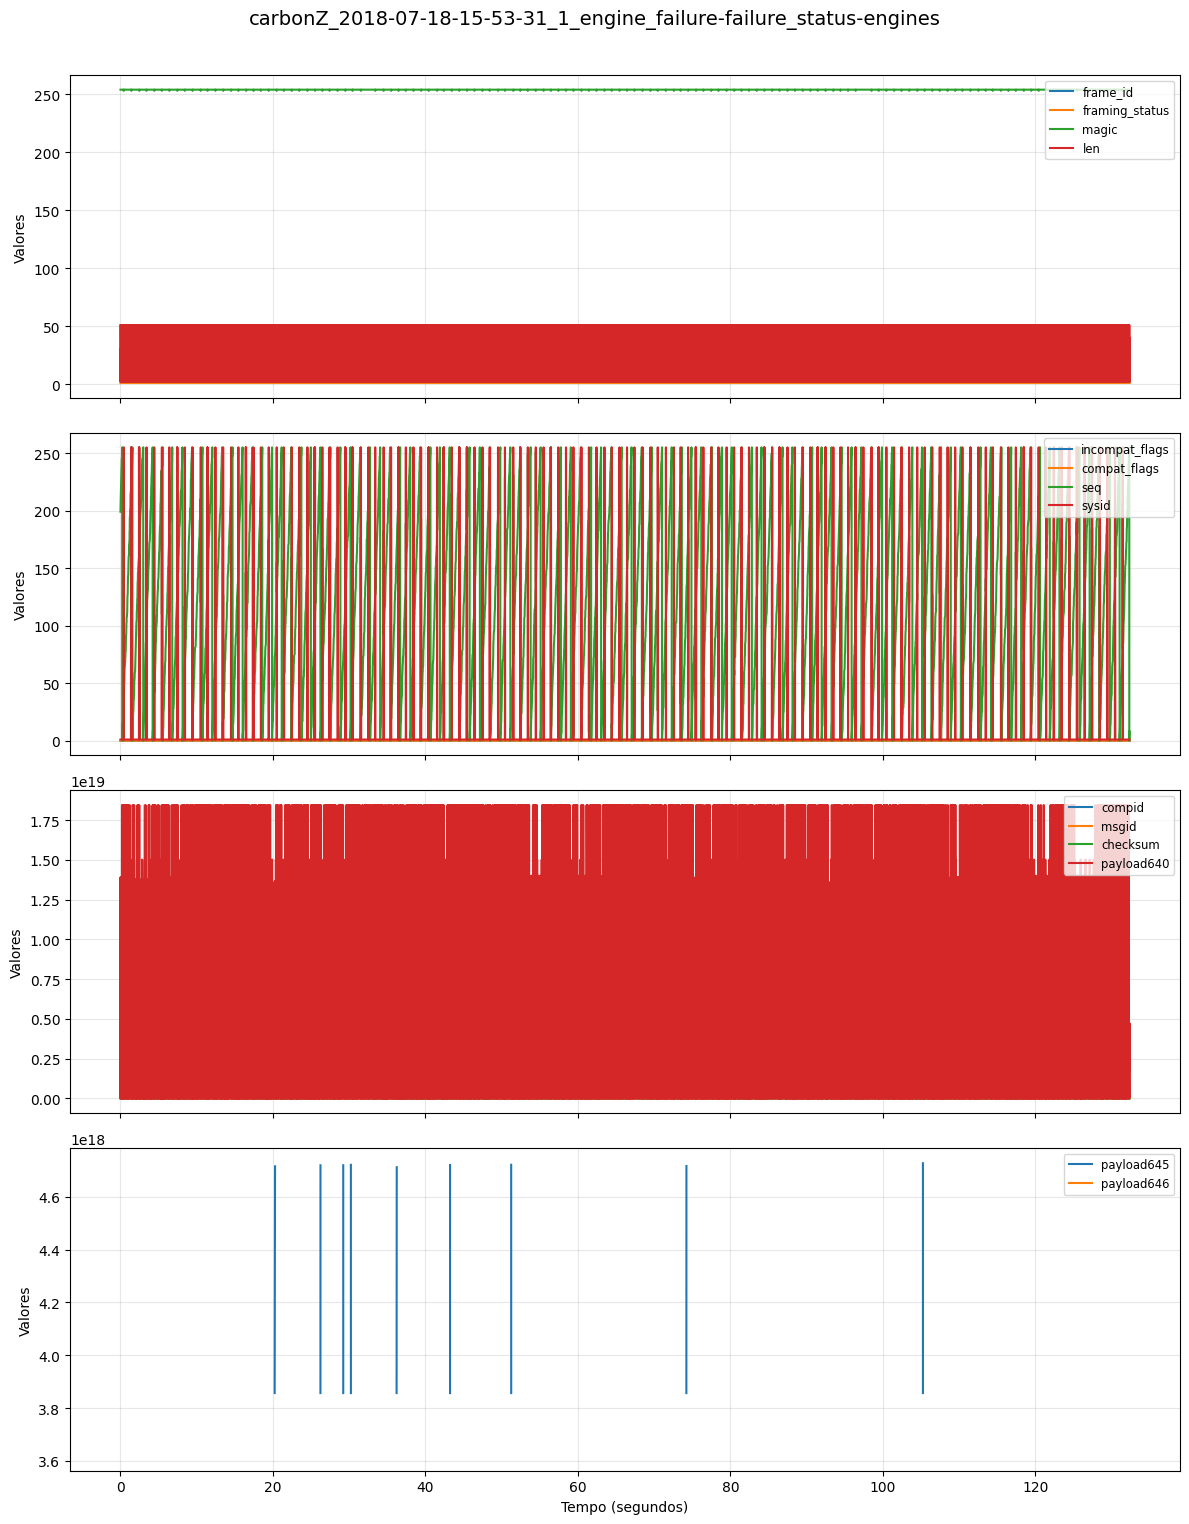

In [38]:
plot_generic_df(df4, titulo_grafico=primeira_chave)

## Observação:

- Não sei o que fazer com as colunas acima, mas talvez sejam úteis para o projeto de segurança Cibernética (Elaine).

In [39]:
# Garantir que ambos estão ordenados pelo tempo
df_merge2 = df_merge2.sort_values('%time')
df4 = df4.sort_values('%time')

# Unir os comandos de rádio ao dataframe principal
df_merge3 = pd.merge_asof(df_merge2, df4, on='%time', direction='backward')


print("Colunas agora no DF final:", df_merge3.columns.tolist())

Colunas agora no DF final: ['%time', 'field.header.seq_x', 'field.header.stamp_x', 'field.header.frame_id_x', 'field.twist.linear.x', 'field.twist.linear.y', 'field.twist.linear.z', 'field.twist.angular.x', 'field.twist.angular.y', 'field.twist.angular.z', 'engine_status', 'rc_aileron', 'rc_elevator', 'rc_throttle', 'rc_rudder', 'rc_signal_strength', 'field.header.seq_y', 'field.header.stamp_y', 'field.header.frame_id_y', 'field.framing_status', 'field.magic', 'field.len', 'field.incompat_flags', 'field.compat_flags', 'field.seq', 'field.sysid', 'field.compid', 'field.msgid', 'field.checksum', 'field.payload640', 'field.payload641', 'field.payload642', 'field.payload643', 'field.payload644', 'field.payload645', 'field.payload646']


In [40]:
df_merge3

,%time,field.header.seq_x,field.header.stamp_x,field.header.frame_id_x,field.twist.linear.x,field.twist.linear.y,field.twist.linear.z,field.twist.angular.x,field.twist.angular.y,field.twist.angular.z,...,field.compid,field.msgid,field.checksum,field.payload640,field.payload641,field.payload642,field.payload643,field.payload644,field.payload645,field.payload646
0,1531943810933587063,1286,1531943810933254299,map,19.086618,-1.989246,0.0,0.0,0.0,0.0,...,1,24,41360,917028000,15015085081720112105,31244005883108262,432081699245590399,,NaN,NaN
1,1531943811143678844,1287,1531943811143058500,map,19.315361,-0.752150,0.0,0.0,0.0,0.0,...,1,24,54181,917229000,15015087044520166353,31244005883108442,4611422153421031309,,NaN,NaN
2,1531943811338236330,1288,1531943811337205271,map,19.146784,-0.350922,0.0,0.0,0.0,0.0,...,1,24,18729,917430000,15015088968665514951,31243992998206794,71794828535465851,,NaN,NaN
3,1531943811549229158,1289,1531943811548014901,map,18.873702,-0.487633,0.0,0.0,0.0,0.0,...,1,24,22680,917629000,15015090892810863552,31243992998207114,4539365658889815904,,NaN,NaN
4,1531943811742729793,1290,1531943811741930763,map,18.355274,-0.416539,0.0,0.0,0.0,0.0,...,1,24,61965,917829000,15015092791186408376,31243992998207564,13690680101705484076,,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
657,1531943942336272938,1943,1531943942335946573,map,-11.029684,-1.563865,0.0,0.0,0.0,0.0,...,1,24,58641,1048429000,15015133855368716349,30681025864906828,13834797489922835546,,NaN,NaN
658,1531943942544529002,1944,1531943942544183982,map,-11.015610,-1.192788,0.0,0.0,0.0,0.0,...,1,24,58644,1048630000,15015132738677219363,30681025864906388,71797028690986068,,NaN,NaN
659,1531943942747957693,1945,1531943942747002215,map,-10.878427,-0.829410,0.0,0.0,0.0,0.0,...,1,24,1550,1048829000,15015131626280689679,30681025864906008,13834797489947149379,,NaN,NaN
660,1531943942945854826,1946,1531943942945630604,map,-10.699969,-0.463429,0.0,0.0,0.0,0.0,...,1,24,61747,1049029000,15015130531064029187,30681025864905638,13762739895921542191,,NaN,NaN


# Dataframe 5

In [41]:
i = 4
list(dfs.keys())[i]

'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-raw-fix'

In [42]:
chave = list(dfs.keys())[i]
df5 = dfs[chave]


In [43]:
df5

,%time,field.header.seq,field.header.stamp,field.header.frame_id,field.status.status,field.status.service,field.latitude,field.longitude,field.altitude,field.position_covariance0,field.position_covariance1,field.position_covariance2,field.position_covariance3,field.position_covariance4,field.position_covariance5,field.position_covariance6,field.position_covariance7,field.position_covariance8,field.position_covariance_type
0,1531943810933532215,1286,1531943810933254299,base_link,0,1,40.591460,-79.899537,349.262178,0.4356,0.0,0.0,0.0,0.4356,0.0,0.0,0.0,1.7424,1
1,1531943811143669052,1287,1531943811143058500,base_link,0,1,40.591458,-79.899491,349.442225,0.4356,0.0,0.0,0.0,0.4356,0.0,0.0,0.0,1.7424,1
2,1531943811337496467,1288,1531943811337205271,base_link,0,1,40.591457,-79.899447,349.682272,0.3969,0.0,0.0,0.0,0.3969,0.0,0.0,0.0,1.5876,1
3,1531943811548847210,1289,1531943811548014901,base_link,0,1,40.591456,-79.899402,350.002318,0.3969,0.0,0.0,0.0,0.3969,0.0,0.0,0.0,1.5876,1
4,1531943811742431204,1290,1531943811741930763,base_link,0,1,40.591455,-79.899358,350.452363,0.3969,0.0,0.0,0.0,0.3969,0.0,0.0,0.0,1.5876,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
657,1531943942336218154,1943,1531943942335946573,base_link,0,1,40.590547,-79.898402,340.213721,0.3481,0.0,0.0,0.0,0.3481,0.0,0.0,0.0,1.3924,1
658,1531943942544452235,1944,1531943942544183982,base_link,0,1,40.590544,-79.898428,339.773696,0.3481,0.0,0.0,0.0,0.3481,0.0,0.0,0.0,1.3924,1
659,1531943942747472386,1945,1531943942747002215,base_link,0,1,40.590542,-79.898454,339.393670,0.3481,0.0,0.0,0.0,0.3481,0.0,0.0,0.0,1.3924,1
660,1531943942945848010,1946,1531943942945630604,base_link,0,1,40.590541,-79.898479,339.023645,0.3481,0.0,0.0,0.0,0.3481,0.0,0.0,0.0,1.3924,1


In [44]:
df5.columns

Index(['%time', 'field.header.seq', 'field.header.stamp',
       'field.header.frame_id', 'field.status.status', 'field.status.service',
       'field.latitude', 'field.longitude', 'field.altitude',
       'field.position_covariance0', 'field.position_covariance1',
       'field.position_covariance2', 'field.position_covariance3',
       'field.position_covariance4', 'field.position_covariance5',
       'field.position_covariance6', 'field.position_covariance7',
       'field.position_covariance8', 'field.position_covariance_type'],
      dtype='str')

## Interpretando as Colunas

- %time e field.header.stamp: São os marcadores de tempo. O %time geralmente é o tempo de recepção do sistema, enquanto o stamp é quando o sensor gerou o dado. 

1. Coordenadas e Altitude

- field.latitude / field.longitude: Localização global do Carbon-Z. Útil se você quiser plotar o rastro do voo em um mapa para ver se ele saiu de curso após a falha.

- field.altitude: É a altitude geodésica. Como o Carbon-Z é um avião, monitorar a perda de altitude aqui é o seu principal indicador de que o motor parou de fornecer empuxo para manter o voo nivelado.

2. Confiança do Sinal (Covariância)

- field.position_covariance (0 a 8): Estas colunas formam uma matriz 3×3. Elas indicam a incerteza do GPS nos eixos X, Y e Z.

    - Valores baixos = GPS preciso.

    - Valores altos = O GPS está "perdido" ou sofrendo interferência.

- field.status.status: Indica se o GPS tem um "fix" (conexão). No dataset ALFA, você espera que seja 0 (Global Fix) ou maior.

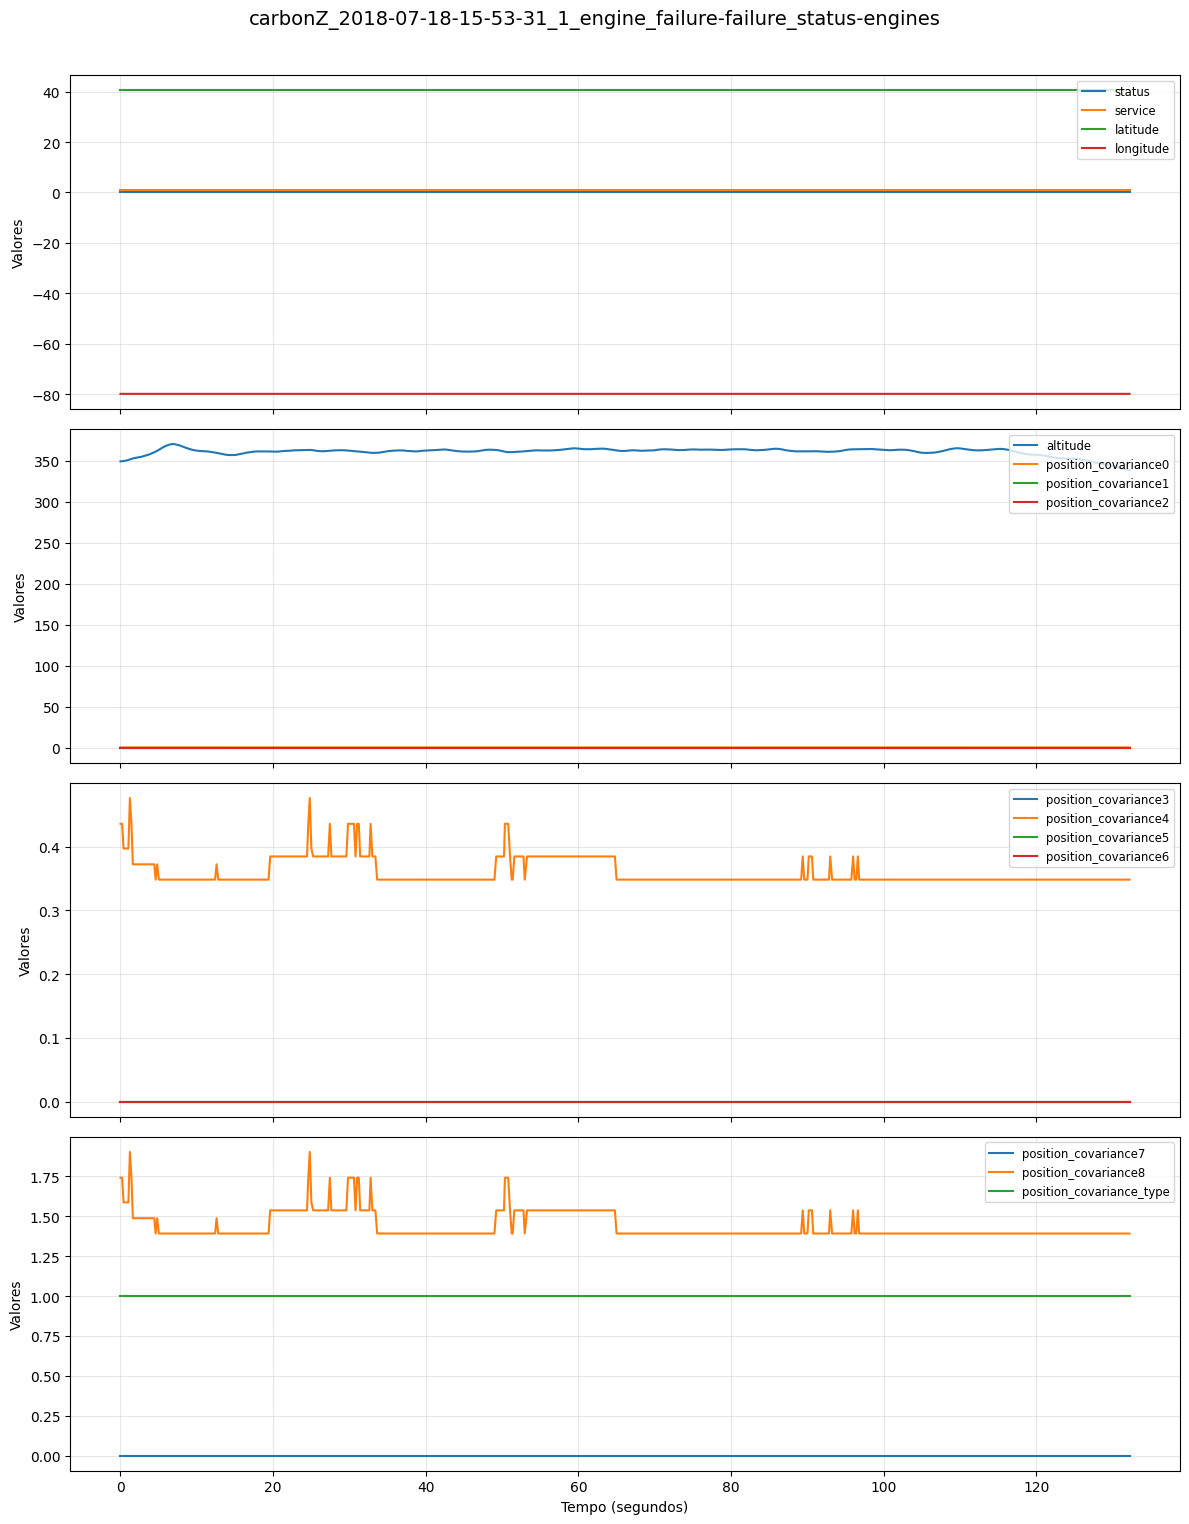

In [45]:
plot_generic_df(df5, titulo_grafico=primeira_chave)

## Observação:

1 - As covariâncias podem ser usadas para treinar um modelo específico para detectar falhas de sensores GPS.

2 - Há perda de altitude justamente quando o engine_status muda de 0 para 1, sinalizando uma falha do motor.

In [46]:
# Garantir que ambos estão ordenados pelo tempo
df_merge3 = df_merge3.sort_values('%time')
df5 = df5.sort_values('%time')

# Unir os comandos de rádio ao dataframe principal
df_merge4 = pd.merge_asof(df_merge3, df5, on='%time', direction='backward')


print("Colunas agora no DF final:", df_merge4.columns.tolist())

Colunas agora no DF final: ['%time', 'field.header.seq_x', 'field.header.stamp_x', 'field.header.frame_id_x', 'field.twist.linear.x', 'field.twist.linear.y', 'field.twist.linear.z', 'field.twist.angular.x', 'field.twist.angular.y', 'field.twist.angular.z', 'engine_status', 'rc_aileron', 'rc_elevator', 'rc_throttle', 'rc_rudder', 'rc_signal_strength', 'field.header.seq_y', 'field.header.stamp_y', 'field.header.frame_id_y', 'field.framing_status', 'field.magic', 'field.len', 'field.incompat_flags', 'field.compat_flags', 'field.seq', 'field.sysid', 'field.compid', 'field.msgid', 'field.checksum', 'field.payload640', 'field.payload641', 'field.payload642', 'field.payload643', 'field.payload644', 'field.payload645', 'field.payload646', 'field.header.seq', 'field.header.stamp', 'field.header.frame_id', 'field.status.status', 'field.status.service', 'field.latitude', 'field.longitude', 'field.altitude', 'field.position_covariance0', 'field.position_covariance1', 'field.position_covariance2', 

In [47]:
df_merge4

,%time,field.header.seq_x,field.header.stamp_x,field.header.frame_id_x,field.twist.linear.x,field.twist.linear.y,field.twist.linear.z,field.twist.angular.x,field.twist.angular.y,field.twist.angular.z,...,field.position_covariance0,field.position_covariance1,field.position_covariance2,field.position_covariance3,field.position_covariance4,field.position_covariance5,field.position_covariance6,field.position_covariance7,field.position_covariance8,field.position_covariance_type
0,1531943810933587063,1286,1531943810933254299,map,19.086618,-1.989246,0.0,0.0,0.0,0.0,...,0.4356,0.0,0.0,0.0,0.4356,0.0,0.0,0.0,1.7424,1
1,1531943811143678844,1287,1531943811143058500,map,19.315361,-0.752150,0.0,0.0,0.0,0.0,...,0.4356,0.0,0.0,0.0,0.4356,0.0,0.0,0.0,1.7424,1
2,1531943811338236330,1288,1531943811337205271,map,19.146784,-0.350922,0.0,0.0,0.0,0.0,...,0.3969,0.0,0.0,0.0,0.3969,0.0,0.0,0.0,1.5876,1
3,1531943811549229158,1289,1531943811548014901,map,18.873702,-0.487633,0.0,0.0,0.0,0.0,...,0.3969,0.0,0.0,0.0,0.3969,0.0,0.0,0.0,1.5876,1
4,1531943811742729793,1290,1531943811741930763,map,18.355274,-0.416539,0.0,0.0,0.0,0.0,...,0.3969,0.0,0.0,0.0,0.3969,0.0,0.0,0.0,1.5876,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
657,1531943942336272938,1943,1531943942335946573,map,-11.029684,-1.563865,0.0,0.0,0.0,0.0,...,0.3481,0.0,0.0,0.0,0.3481,0.0,0.0,0.0,1.3924,1
658,1531943942544529002,1944,1531943942544183982,map,-11.015610,-1.192788,0.0,0.0,0.0,0.0,...,0.3481,0.0,0.0,0.0,0.3481,0.0,0.0,0.0,1.3924,1
659,1531943942747957693,1945,1531943942747002215,map,-10.878427,-0.829410,0.0,0.0,0.0,0.0,...,0.3481,0.0,0.0,0.0,0.3481,0.0,0.0,0.0,1.3924,1
660,1531943942945854826,1946,1531943942945630604,map,-10.699969,-0.463429,0.0,0.0,0.0,0.0,...,0.3481,0.0,0.0,0.0,0.3481,0.0,0.0,0.0,1.3924,1


In [48]:
df_merge4.columns

Index(['%time', 'field.header.seq_x', 'field.header.stamp_x',
       'field.header.frame_id_x', 'field.twist.linear.x',
       'field.twist.linear.y', 'field.twist.linear.z', 'field.twist.angular.x',
       'field.twist.angular.y', 'field.twist.angular.z', 'engine_status',
       'rc_aileron', 'rc_elevator', 'rc_throttle', 'rc_rudder',
       'rc_signal_strength', 'field.header.seq_y', 'field.header.stamp_y',
       'field.header.frame_id_y', 'field.framing_status', 'field.magic',
       'field.len', 'field.incompat_flags', 'field.compat_flags', 'field.seq',
       'field.sysid', 'field.compid', 'field.msgid', 'field.checksum',
       'field.payload640', 'field.payload641', 'field.payload642',
       'field.payload643', 'field.payload644', 'field.payload645',
       'field.payload646', 'field.header.seq', 'field.header.stamp',
       'field.header.frame_id', 'field.status.status', 'field.status.service',
       'field.latitude', 'field.longitude', 'field.altitude',
       'field.positi

# Dataframe 6

In [49]:
i = 5
list(dfs.keys())[i]

'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-rel_alt'

In [50]:
chave = list(dfs.keys())[i]
df6 = dfs[chave]


In [51]:
df6

,%time,field.data
0,1531943810885789946,35.605
1,1531943811114679502,35.869
2,1531943811369277886,36.408
3,1531943811635856276,37.247
4,1531943811883604827,38.126
...,...,...
539,1531943941986542159,30.196
540,1531943942267743061,29.587
541,1531943942512285883,29.136
542,1531943942787274466,28.662


In [52]:
df6.columns

Index(['%time', 'field.data'], dtype='str')

In [53]:
df6 = df6.rename(columns={'field.data': 'altitude_relativa'})

In [54]:
df6

,%time,altitude_relativa
0,1531943810885789946,35.605
1,1531943811114679502,35.869
2,1531943811369277886,36.408
3,1531943811635856276,37.247
4,1531943811883604827,38.126
...,...,...
539,1531943941986542159,30.196
540,1531943942267743061,29.587
541,1531943942512285883,29.136
542,1531943942787274466,28.662


## Interpretando as Colunas

- %time : Marcadores de tempo. O %time geralmente é o tempo de recepção do sistema. 

1. O que é o field.data neste arquivo?

Diferente da altitude do GPS (que é em relação ao nível do mar), a Relative Altitude é a altura do drone em relação ao ponto de onde ele decolou (o "Home").

- Importância: Para detectar falhas de motor em aviões, esta é a coluna mais intuitiva. Se o field.data começa a cair consistentemente enquanto o piloto mantém o acelerador alto, você tem a prova geométrica da falha.

- Dica: Renomeie essa coluna para altitude_relativa antes do merge para não confundir com a altitude global.

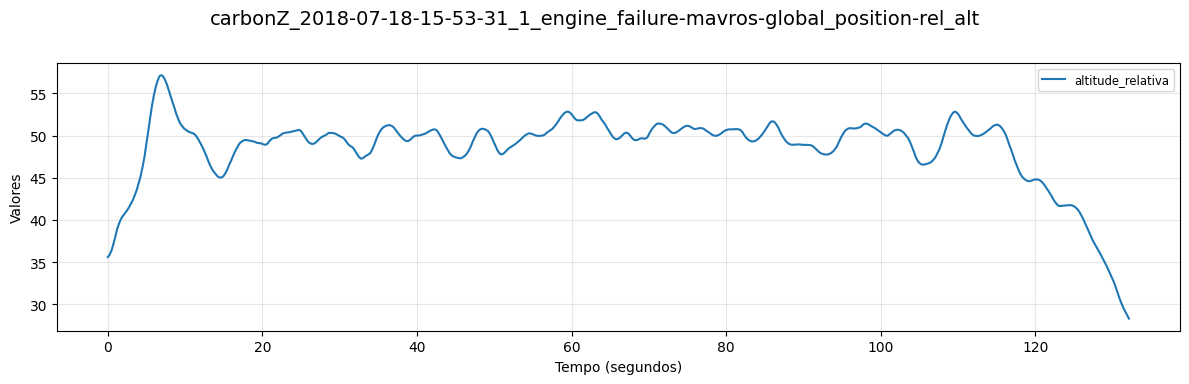

In [55]:
plot_generic_df(df6, titulo_grafico=chave)

## Observação:

1 - Na análise dos primeiros gráficos, ficou claro que o avião começa a cair por volta de 116 segundos. Isso pode ser confirmado no gráfico acima.


In [56]:
df_merge5 = pd.merge_asof(
    df_merge4, 
    df6[['%time', 'altitude_relativa']], 
    on='%time', 
    direction='backward'
)

In [57]:
df_merge5

,%time,field.header.seq_x,field.header.stamp_x,field.header.frame_id_x,field.twist.linear.x,field.twist.linear.y,field.twist.linear.z,field.twist.angular.x,field.twist.angular.y,field.twist.angular.z,...,field.position_covariance1,field.position_covariance2,field.position_covariance3,field.position_covariance4,field.position_covariance5,field.position_covariance6,field.position_covariance7,field.position_covariance8,field.position_covariance_type,altitude_relativa
0,1531943810933587063,1286,1531943810933254299,map,19.086618,-1.989246,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.4356,0.0,0.0,0.0,1.7424,1,35.605
1,1531943811143678844,1287,1531943811143058500,map,19.315361,-0.752150,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.4356,0.0,0.0,0.0,1.7424,1,35.869
2,1531943811338236330,1288,1531943811337205271,map,19.146784,-0.350922,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.3969,0.0,0.0,0.0,1.5876,1,35.869
3,1531943811549229158,1289,1531943811548014901,map,18.873702,-0.487633,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.3969,0.0,0.0,0.0,1.5876,1,36.408
4,1531943811742729793,1290,1531943811741930763,map,18.355274,-0.416539,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.3969,0.0,0.0,0.0,1.5876,1,37.247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
657,1531943942336272938,1943,1531943942335946573,map,-11.029684,-1.563865,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.3481,0.0,0.0,0.0,1.3924,1,29.587
658,1531943942544529002,1944,1531943942544183982,map,-11.015610,-1.192788,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.3481,0.0,0.0,0.0,1.3924,1,29.136
659,1531943942747957693,1945,1531943942747002215,map,-10.878427,-0.829410,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.3481,0.0,0.0,0.0,1.3924,1,29.136
660,1531943942945854826,1946,1531943942945630604,map,-10.699969,-0.463429,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.3481,0.0,0.0,0.0,1.3924,1,28.662


In [58]:
# Limpeza de colunas duplicadas de 'header' que poluem o visual
cols_to_keep = [c for c in df_merge5.columns if not ('_x' in c or '_y' in c or 'header' in c)]
df6_final = df_merge5[cols_to_keep]

print("Colunas consolidadas no df_final:")
print(df6_final.columns.tolist())

Colunas consolidadas no df_final:
['%time', 'field.twist.linear.x', 'field.twist.linear.y', 'field.twist.linear.z', 'field.twist.angular.x', 'field.twist.angular.y', 'field.twist.angular.z', 'engine_status', 'rc_aileron', 'rc_elevator', 'rc_throttle', 'rc_rudder', 'rc_signal_strength', 'field.framing_status', 'field.magic', 'field.len', 'field.incompat_flags', 'field.compat_flags', 'field.seq', 'field.sysid', 'field.compid', 'field.msgid', 'field.checksum', 'field.payload640', 'field.payload641', 'field.payload642', 'field.payload643', 'field.payload644', 'field.payload645', 'field.payload646', 'field.status.status', 'field.status.service', 'field.latitude', 'field.longitude', 'field.altitude', 'field.position_covariance0', 'field.position_covariance1', 'field.position_covariance2', 'field.position_covariance3', 'field.position_covariance4', 'field.position_covariance5', 'field.position_covariance6', 'field.position_covariance7', 'field.position_covariance8', 'field.position_covariance

In [59]:
df6_final

,%time,field.twist.linear.x,field.twist.linear.y,field.twist.linear.z,field.twist.angular.x,field.twist.angular.y,field.twist.angular.z,engine_status,rc_aileron,rc_elevator,...,field.position_covariance1,field.position_covariance2,field.position_covariance3,field.position_covariance4,field.position_covariance5,field.position_covariance6,field.position_covariance7,field.position_covariance8,field.position_covariance_type,altitude_relativa
0,1531943810933587063,19.086618,-1.989246,0.0,0.0,0.0,0.0,0,1626,1532,...,0.0,0.0,0.0,0.4356,0.0,0.0,0.0,1.7424,1,35.605
1,1531943811143678844,19.315361,-0.752150,0.0,0.0,0.0,0.0,0,1626,1532,...,0.0,0.0,0.0,0.4356,0.0,0.0,0.0,1.7424,1,35.869
2,1531943811338236330,19.146784,-0.350922,0.0,0.0,0.0,0.0,0,1515,1552,...,0.0,0.0,0.0,0.3969,0.0,0.0,0.0,1.5876,1,35.869
3,1531943811549229158,18.873702,-0.487633,0.0,0.0,0.0,0.0,0,1515,1552,...,0.0,0.0,0.0,0.3969,0.0,0.0,0.0,1.5876,1,36.408
4,1531943811742729793,18.355274,-0.416539,0.0,0.0,0.0,0.0,0,1515,1552,...,0.0,0.0,0.0,0.3969,0.0,0.0,0.0,1.5876,1,37.247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
657,1531943942336272938,-11.029684,-1.563865,0.0,0.0,0.0,0.0,1,1514,1552,...,0.0,0.0,0.0,0.3481,0.0,0.0,0.0,1.3924,1,29.587
658,1531943942544529002,-11.015610,-1.192788,0.0,0.0,0.0,0.0,1,1514,1552,...,0.0,0.0,0.0,0.3481,0.0,0.0,0.0,1.3924,1,29.136
659,1531943942747957693,-10.878427,-0.829410,0.0,0.0,0.0,0.0,1,1514,1552,...,0.0,0.0,0.0,0.3481,0.0,0.0,0.0,1.3924,1,29.136
660,1531943942945854826,-10.699969,-0.463429,0.0,0.0,0.0,0.0,1,1514,1552,...,0.0,0.0,0.0,0.3481,0.0,0.0,0.0,1.3924,1,28.662


# Dataframe 7

In [60]:
i = 6
list(dfs.keys())[i]

'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-imu-data_raw'

In [61]:
chave = list(dfs.keys())[i]
df7 = dfs[chave]


In [62]:
df7

,%time,field.header.seq,field.header.stamp,field.header.frame_id,field.orientation.x,field.orientation.y,field.orientation.z,field.orientation.w,field.orientation_covariance0,field.orientation_covariance1,...,field.linear_acceleration.z,field.linear_acceleration_covariance0,field.linear_acceleration_covariance1,field.linear_acceleration_covariance2,field.linear_acceleration_covariance3,field.linear_acceleration_covariance4,field.linear_acceleration_covariance5,field.linear_acceleration_covariance6,field.linear_acceleration_covariance7,field.linear_acceleration_covariance8
0,1531943810879492554,2310,1531943810878600982,base_link,0.0,0.0,0.0,0.0,-1.0,0.0,...,14.082349,9.000000e-08,0.0,0.0,0.0,9.000000e-08,0.0,0.0,0.0,9.000000e-08
1,1531943810955271265,2311,1531943810954521707,base_link,0.0,0.0,0.0,0.0,-1.0,0.0,...,14.817848,9.000000e-08,0.0,0.0,0.0,9.000000e-08,0.0,0.0,0.0,9.000000e-08
2,1531943811062404745,2312,1531943811058928693,base_link,0.0,0.0,0.0,0.0,-1.0,0.0,...,14.513842,9.000000e-08,0.0,0.0,0.0,9.000000e-08,0.0,0.0,0.0,9.000000e-08
3,1531943811149599633,2313,1531943811149100183,base_link,0.0,0.0,0.0,0.0,-1.0,0.0,...,14.043123,9.000000e-08,0.0,0.0,0.0,9.000000e-08,0.0,0.0,0.0,9.000000e-08
4,1531943811240830629,2314,1531943811238598369,base_link,0.0,0.0,0.0,0.0,-1.0,0.0,...,12.189666,9.000000e-08,0.0,0.0,0.0,9.000000e-08,0.0,0.0,0.0,9.000000e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1319,1531943942782982991,3629,1531943942780845478,base_link,0.0,0.0,0.0,0.0,-1.0,0.0,...,9.394771,9.000000e-08,0.0,0.0,0.0,9.000000e-08,0.0,0.0,0.0,9.000000e-08
1320,1531943942877527380,3630,1531943942876917562,base_link,0.0,0.0,0.0,0.0,-1.0,0.0,...,10.159689,9.000000e-08,0.0,0.0,0.0,9.000000e-08,0.0,0.0,0.0,9.000000e-08
1321,1531943942953407323,3631,1531943942953041951,base_link,0.0,0.0,0.0,0.0,-1.0,0.0,...,10.414662,9.000000e-08,0.0,0.0,0.0,9.000000e-08,0.0,0.0,0.0,9.000000e-08
1322,1531943943070292759,3632,1531943943068787079,base_link,0.0,0.0,0.0,0.0,-1.0,0.0,...,11.356101,9.000000e-08,0.0,0.0,0.0,9.000000e-08,0.0,0.0,0.0,9.000000e-08


In [63]:
df7.columns

Index(['%time', 'field.header.seq', 'field.header.stamp',
       'field.header.frame_id', 'field.orientation.x', 'field.orientation.y',
       'field.orientation.z', 'field.orientation.w',
       'field.orientation_covariance0', 'field.orientation_covariance1',
       'field.orientation_covariance2', 'field.orientation_covariance3',
       'field.orientation_covariance4', 'field.orientation_covariance5',
       'field.orientation_covariance6', 'field.orientation_covariance7',
       'field.orientation_covariance8', 'field.angular_velocity.x',
       'field.angular_velocity.y', 'field.angular_velocity.z',
       'field.angular_velocity_covariance0',
       'field.angular_velocity_covariance1',
       'field.angular_velocity_covariance2',
       'field.angular_velocity_covariance3',
       'field.angular_velocity_covariance4',
       'field.angular_velocity_covariance5',
       'field.angular_velocity_covariance6',
       'field.angular_velocity_covariance7',
       'field.angular_veloci

## Interpretando as Colunas

o IMU (Inertial Measurement Unit) é, provavelmente, o arquivo mais importante para detectar uma falha de motor de forma precoce, antes mesmo do GPS notar que o avião está perdendo altitude.

Diferente do GPS, que olha para o "onde", o IMU olha para o "como" o avião está se sentindo. Aqui está a tradução técnica das colunas:

- %time e field.header.stamp: São os marcadores de tempo. O %time geralmente é o tempo de recepção do sistema, enquanto o stamp é quando o sensor gerou o dado. 

1. Orientação (Quatérnios: x, y, z, w)

Estas quatro colunas descrevem a posição do avião no espaço.

- Nota Matemática: No ROS, a orientação é dada em Quatérnios para evitar o "Gimbal Lock". Se você quiser ver graus (Roll, Pitch, Yaw), precisará convertê-los.

- Uso na Falha: Quando o motor para, o nariz do avião tende a cair (Pitch negativo) para ganhar velocidade de planeio, e as asas podem oscilar (Roll) se o piloto tentar compensar a perda de torque.

2. Velocidade Angular (angular_velocity.x, y, z)

Mede o quão rápido o avião está girando em torno de seus próprios eixos.

- Unidade: Radianos por segundo (rad/s).

- Uso na Falha: No exato momento em que o motor morre, a vibração constante do motor cessa. Você verá uma mudança no "ruído" dessas taxas.

3. Aceleração Linear (linear_acceleration.x, y, z)

Mede as forças G agindo sobre o avião.

- Fato Curioso: Em repouso no solo, o linear_acceleration.z será aproximadamente 9,81m/s2 (a gravidade da Terra).

- Uso na Falha: A coluna .x (para frente) é vital. Se o motor apaga, a aceleração positiva cessa imediatamente e o arrasto começa a desacelerar o avião (aceleração negativa).

4. Em robótica e no ROS, a covariância indica o grau de incerteza do sensor. Elas formam uma matriz 3×3 (por isso são 9 colunas, de 0 a 8).

    Valores baixos: O sensor está muito confiante de que a leitura é precisa.

    Valores altos: O dado está "sujo" ou o sensor está sofrendo interferência/vibração excessiva.

Para Cybersecurity, essas colunas são fundamentais: um ataque de injeção de dados muitas vezes esquece de "falsificar" o ruído estatístico. Se a orientação muda bruscamente, mas a covariância permanece perfeitamente estável e baixa, é um sinal de que o dado não veio de um sensor físico real, mas de um script.


Para Detecção de Falhas: O IMU é o primeiro a saber da falha. O GPS demora para atualizar a posição, mas o acelerômetro sente a perda de empuxo instantaneamente. Um modelo de IA que combina linear_acceleration.x (IMU) com rc_throttle (Controle) é extremamente robusto.

Para Segurança Cibernética: O IMU é muito difícil de falsificar perfeitamente. Se um atacante injetar dados de GPS dizendo que o avião está subindo, mas o IMU mostrar que não houve aceleração vertical (z) condizente com essa subida, temos uma prova de Ataque de Inconsistência Sensorial.

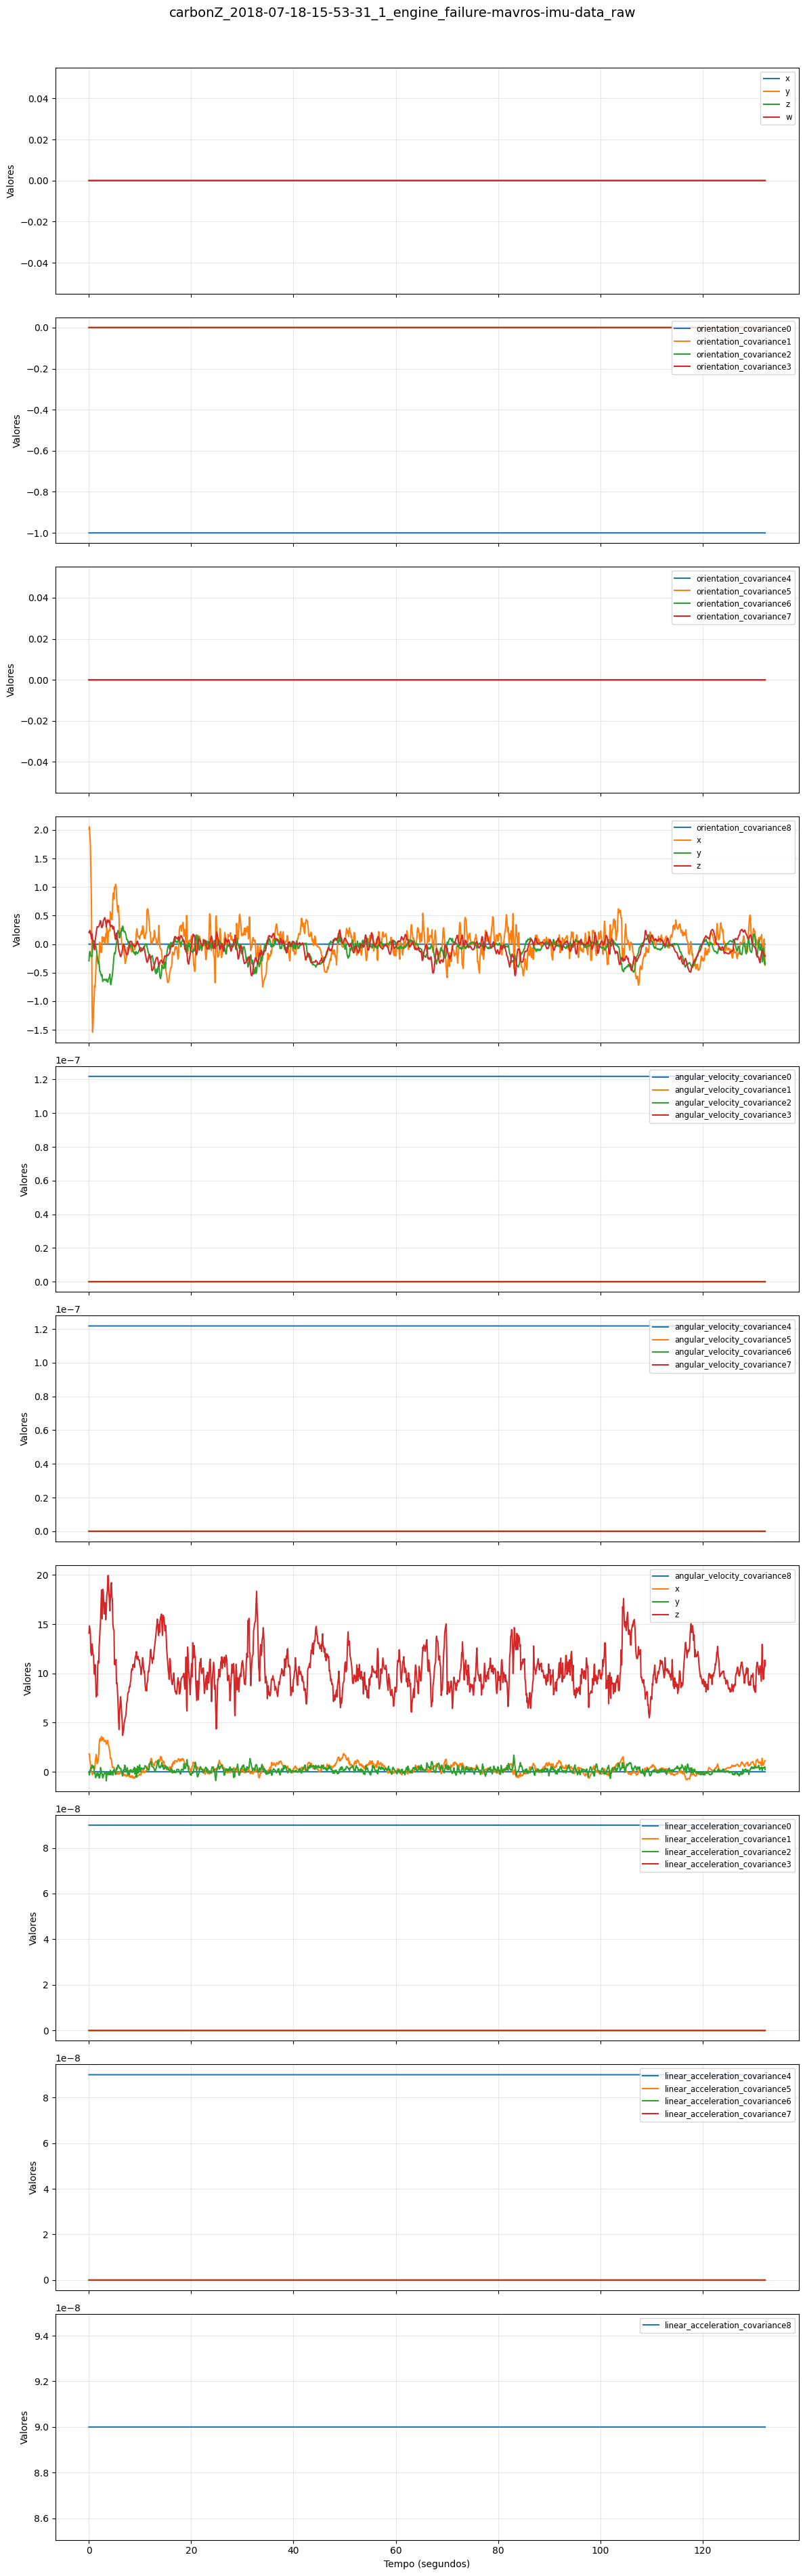

In [64]:
plot_generic_df(df7 , titulo_grafico=chave)

# Observações:

- Todas as colunas de orientação são nulas, como podemos ver abaixo. Por isso vamos eliminá-las deste arquivo.

- A covariância é uma matriz que relaciona os três eixos (x,y,z):

### Representação da Matriz de Covariância ($3 \times 3$)

Esta matriz descreve a incerteza dos sensores nos eixos espaciais. A diagonal principal representa a variância (ruído individual), enquanto os demais campos representam a correlação entre os eixos.

| | **Eixo X** | **Eixo Y** | **Eixo Z** |
| :--- | :---: | :---: | :---: |
| **Eixo X** | **Var(X)** | Cov(X, Y) | Cov(X, Z) |
| **Eixo Y** | Cov(Y, X) | **Var(Y)** | Cov(Y, Z) |
| **Eixo Z** | Cov(Z, X) | Cov(Z, Y) | **Var(Z)** |

---


- As colunas 0, 4 e 8 (a diagonal) são as mais importantes: elas indicam a incerteza individual de cada eixo.

- As outras indicam como o erro de um eixo interfere no outro (correlação).

In [65]:
df7['field.orientation.x'].value_counts()

field.orientation.x
0.0    1324
Name: count, dtype: int64

In [66]:
df7['field.orientation.y'].value_counts()

field.orientation.y
0.0    1324
Name: count, dtype: int64

In [67]:
df7['field.orientation.z'].value_counts()

field.orientation.z
0.0    1324
Name: count, dtype: int64

In [68]:
df7['field.orientation.w'].value_counts()

field.orientation.w
0.0    1324
Name: count, dtype: int64

In [69]:
coluns_to_drop = ['field.orientation.x', 'field.orientation.y', 'field.orientation.z', 'field.orientation.w']

df7_no_orientation = df7.drop(columns = coluns_to_drop)

In [70]:
df7_no_orientation.columns

Index(['%time', 'field.header.seq', 'field.header.stamp',
       'field.header.frame_id', 'field.orientation_covariance0',
       'field.orientation_covariance1', 'field.orientation_covariance2',
       'field.orientation_covariance3', 'field.orientation_covariance4',
       'field.orientation_covariance5', 'field.orientation_covariance6',
       'field.orientation_covariance7', 'field.orientation_covariance8',
       'field.angular_velocity.x', 'field.angular_velocity.y',
       'field.angular_velocity.z', 'field.angular_velocity_covariance0',
       'field.angular_velocity_covariance1',
       'field.angular_velocity_covariance2',
       'field.angular_velocity_covariance3',
       'field.angular_velocity_covariance4',
       'field.angular_velocity_covariance5',
       'field.angular_velocity_covariance6',
       'field.angular_velocity_covariance7',
       'field.angular_velocity_covariance8', 'field.linear_acceleration.x',
       'field.linear_acceleration.y', 'field.linear_accele

## Observação:

1 - As covariâncias podem ser usadas para treinar um modelo específico para detectar falhas de sensores GPS.

2 - Há perda de altitude justamente quando o engine_status muda de 0 para 1, sinalizando uma falha do motor.

In [71]:
import pandas as pd

# 1. Garantir que os dados estejam ordenados pelo tempo (obrigatório para merge_asof)
df_merge5 = df_merge5.sort_values('%time')
df7_no_orientation = df7_no_orientation.sort_values('%time')

# 2. Realizar o merge
# Usamos 'backward' para pegar o último dado sensorial conhecido para cada instante de tempo
df_merge6 = pd.merge_asof(
    df_merge5, 
    df7_no_orientation, 
    on='%time', 
    direction='backward',
    suffixes=('', '_imu') # Adiciona sufixo se houver colunas com nomes repetidos
)

print(f"Novo formato do DataFrame: {df_merge6.shape}")

Novo formato do DataFrame: (662, 91)


In [72]:
df_merge6

,%time,field.header.seq_x,field.header.stamp_x,field.header.frame_id_x,field.twist.linear.x,field.twist.linear.y,field.twist.linear.z,field.twist.angular.x,field.twist.angular.y,field.twist.angular.z,...,field.linear_acceleration.z,field.linear_acceleration_covariance0,field.linear_acceleration_covariance1,field.linear_acceleration_covariance2,field.linear_acceleration_covariance3,field.linear_acceleration_covariance4,field.linear_acceleration_covariance5,field.linear_acceleration_covariance6,field.linear_acceleration_covariance7,field.linear_acceleration_covariance8
0,1531943810933587063,1286,1531943810933254299,map,19.086618,-1.989246,0.0,0.0,0.0,0.0,...,14.082349,9.000000e-08,0.0,0.0,0.0,9.000000e-08,0.0,0.0,0.0,9.000000e-08
1,1531943811143678844,1287,1531943811143058500,map,19.315361,-0.752150,0.0,0.0,0.0,0.0,...,14.513842,9.000000e-08,0.0,0.0,0.0,9.000000e-08,0.0,0.0,0.0,9.000000e-08
2,1531943811338236330,1288,1531943811337205271,map,19.146784,-0.350922,0.0,0.0,0.0,0.0,...,12.189666,9.000000e-08,0.0,0.0,0.0,9.000000e-08,0.0,0.0,0.0,9.000000e-08
3,1531943811549229158,1289,1531943811548014901,map,18.873702,-0.487633,0.0,0.0,0.0,0.0,...,12.993811,9.000000e-08,0.0,0.0,0.0,9.000000e-08,0.0,0.0,0.0,9.000000e-08
4,1531943811742729793,1290,1531943811741930763,map,18.355274,-0.416539,0.0,0.0,0.0,0.0,...,11.885660,9.000000e-08,0.0,0.0,0.0,9.000000e-08,0.0,0.0,0.0,9.000000e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
657,1531943942336272938,1943,1531943942335946573,map,-11.029684,-1.563865,0.0,0.0,0.0,0.0,...,10.149883,9.000000e-08,0.0,0.0,0.0,9.000000e-08,0.0,0.0,0.0,9.000000e-08
658,1531943942544529002,1944,1531943942544183982,map,-11.015610,-1.192788,0.0,0.0,0.0,0.0,...,10.767702,9.000000e-08,0.0,0.0,0.0,9.000000e-08,0.0,0.0,0.0,9.000000e-08
659,1531943942747957693,1945,1531943942747002215,map,-10.878427,-0.829410,0.0,0.0,0.0,0.0,...,10.885381,9.000000e-08,0.0,0.0,0.0,9.000000e-08,0.0,0.0,0.0,9.000000e-08
660,1531943942945854826,1946,1531943942945630604,map,-10.699969,-0.463429,0.0,0.0,0.0,0.0,...,10.159689,9.000000e-08,0.0,0.0,0.0,9.000000e-08,0.0,0.0,0.0,9.000000e-08


# Dataframe 8

In [73]:
i = 7
list(dfs.keys())[i]

'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-nav_info-velocity'

In [74]:
chave = list(dfs.keys())[i]
df8 = dfs[chave]


In [75]:
df8

,%time,field.header.seq,field.header.stamp,field.header.frame_id,field.coordinate_frame,field.des_x,field.des_y,field.des_z,field.meas_x,field.meas_y,field.meas_z
0,1531943810861418098,2056,1531943810860063395,NED,5,0.000000,0.0,0.000000e+00,-0.541918,19.508381,0.092209
1,1531943810911778958,2057,1531943810910377632,NED,5,0.000000,0.0,0.000000e+00,-0.264065,19.482502,-0.006710
2,1531943810936678383,2058,1531943810936383635,NED,5,0.000000,0.0,0.000000e+00,-0.001838,19.453337,-0.154981
3,1531943810997375943,2059,1531943810996235413,NED,5,0.000000,0.0,0.000000e+00,0.287959,19.410212,-0.444431
4,1531943811056877552,2060,1531943811056331991,NED,5,0.000000,0.0,0.000000e+00,0.503621,19.352375,-0.739515
...,...,...,...,...,...,...,...,...,...,...,...
2466,1531943942979871463,4522,1531943942979265901,NED,5,-0.000003,-16.0,-3.673940e-22,-0.065727,-10.376916,1.512439
2467,1531943943036136731,4523,1531943943034717066,NED,5,-0.000003,-16.0,-3.673940e-22,0.052570,-10.295895,1.416400
2468,1531943943089040691,4524,1531943943088422138,NED,5,-0.000003,-16.0,-3.673940e-22,0.122478,-10.233899,1.366917
2469,1531943943115857691,4525,1531943943115453824,NED,5,-0.000003,-16.0,-3.673940e-22,0.180388,-10.172915,1.325108


In [76]:
df8.columns

Index(['%time', 'field.header.seq', 'field.header.stamp',
       'field.header.frame_id', 'field.coordinate_frame', 'field.des_x',
       'field.des_y', 'field.des_z', 'field.meas_x', 'field.meas_y',
       'field.meas_z'],
      dtype='str')

## Interpretando as Colunas

- %time : Marcadores de tempo. O %time geralmente é o tempo de recepção do sistema. 

1. O que significam as colunas?


- field.des_x, y, z: Desired Velocity - A velocidade que o piloto automático calculou para cumprir a missão.
- field.meas_x, y, z: Measured Velocity	- A velocidade real lida pelos sensores (fusão de GPS/IMU).



Para Falha de Motor: O motor falha. O controlador do drone percebe que a velocidade está caindo e tenta compensar.

- field.des_x (Desejado) deve aumentar ou se manter alto enquanto o drone tenta recuperar velocidade.

- Ao mesmo tempo, o field.meas_x (Medido) deve cair drasticamente.

- Engenharia de feature: A diferença entre o desejado e o medido (Erro=Desejado−Medido) é um dos indicadores mais fortes de falha mecânica.

Para Cybersecurity: Este arquivo é perfeito para detectar Ataques de Injeção de Controle.

- Se o field.des_x mudar bruscamente sem que o comando de rádio (rc_throttle) tenha mudado, alguém ou algum processo malicioso está injetando setpoints falsos no navegador do drone.

- Se o field.meas_x for exatamente igual ao field.des_x por muito tempo (sem erro nenhum), é um sinal de que os dados são sintéticos, pois sensores reais sempre apresentam um pequeno erro/ruído em relação ao desejado.

In [77]:
mapeamento_nav = {
    'field.des_x': 'vel_desejada_x',
    'field.meas_x': 'vel_medida_x',
    'field.des_y': 'vel_desejada_y',
    'field.meas_y': 'vel_medida_y',
    'field.des_z': 'vel_desejada_z',
    'field.meas_z': 'vel_medida_z'
}
df8 = df8.rename(columns=mapeamento_nav)

# 2. Calcular o erro de rastreamento (Tracking Error)
df8['erro_vel_x'] = df8['vel_desejada_x'] - df8['vel_medida_x']

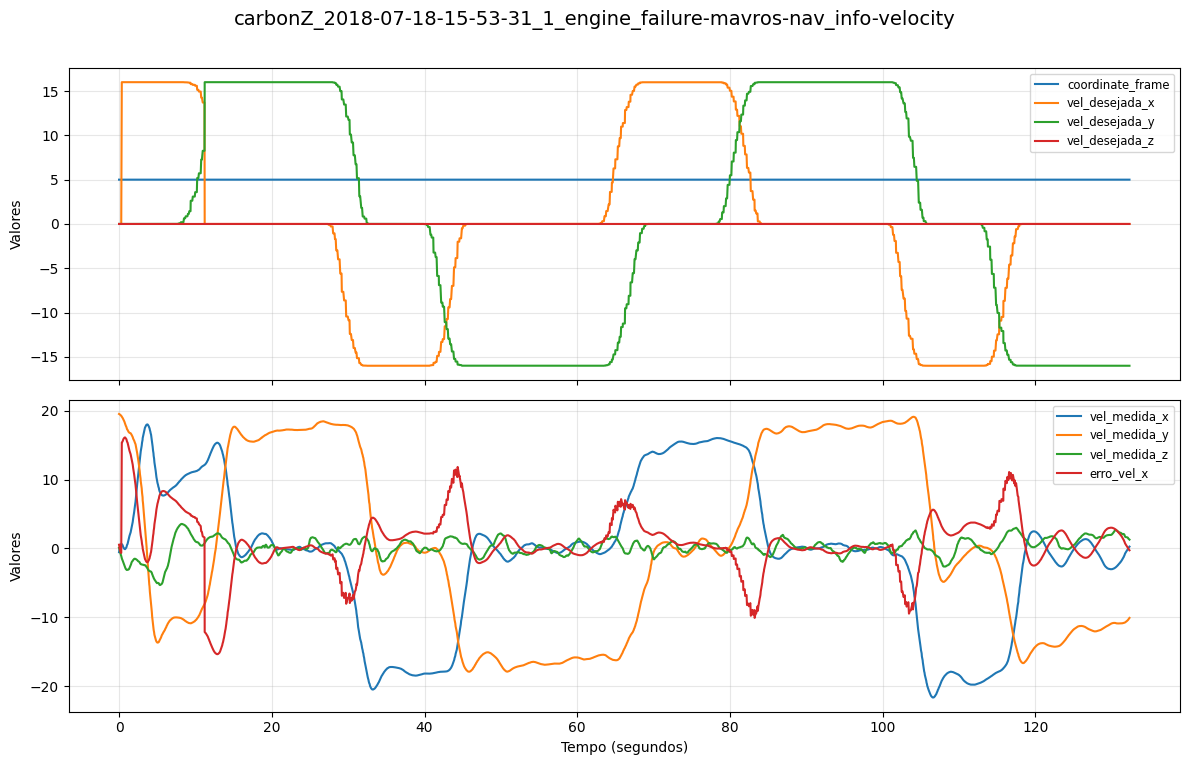

In [78]:
plot_generic_df(df8, titulo_grafico=chave)

# Observação:

- Note que as velocidades medidas ficam oscilam com um amplitude maior quando a falha ocorre (de 116 segundos em diante).

In [79]:
cols_to_drop = [c for c in df8.columns if 'header' in c]

df_merge6= df_merge6.drop(columns=cols_to_drop)

df8 = df8.drop(columns=cols_to_drop)

df8 = df8.drop(columns = 'field.coordinate_frame')


In [80]:
df8

,%time,vel_desejada_x,vel_desejada_y,vel_desejada_z,vel_medida_x,vel_medida_y,vel_medida_z,erro_vel_x
0,1531943810861418098,0.000000,0.0,0.000000e+00,-0.541918,19.508381,0.092209,0.541918
1,1531943810911778958,0.000000,0.0,0.000000e+00,-0.264065,19.482502,-0.006710,0.264065
2,1531943810936678383,0.000000,0.0,0.000000e+00,-0.001838,19.453337,-0.154981,0.001838
3,1531943810997375943,0.000000,0.0,0.000000e+00,0.287959,19.410212,-0.444431,-0.287959
4,1531943811056877552,0.000000,0.0,0.000000e+00,0.503621,19.352375,-0.739515,-0.503621
...,...,...,...,...,...,...,...,...
2466,1531943942979871463,-0.000003,-16.0,-3.673940e-22,-0.065727,-10.376916,1.512439,0.065724
2467,1531943943036136731,-0.000003,-16.0,-3.673940e-22,0.052570,-10.295895,1.416400,-0.052573
2468,1531943943089040691,-0.000003,-16.0,-3.673940e-22,0.122478,-10.233899,1.366917,-0.122481
2469,1531943943115857691,-0.000003,-16.0,-3.673940e-22,0.180388,-10.172915,1.325108,-0.180391


In [81]:
df_merge_final = pd.merge_asof(
    df_merge6.sort_values('%time'),
    df8.sort_values('%time'), 
    on='%time',
    direction='backward'
)

In [82]:
df_merge_final

,%time,field.header.seq_x,field.header.stamp_x,field.header.frame_id_x,field.twist.linear.x,field.twist.linear.y,field.twist.linear.z,field.twist.angular.x,field.twist.angular.y,field.twist.angular.z,...,field.linear_acceleration_covariance6,field.linear_acceleration_covariance7,field.linear_acceleration_covariance8,vel_desejada_x,vel_desejada_y,vel_desejada_z,vel_medida_x,vel_medida_y,vel_medida_z,erro_vel_x
0,1531943810933587063,1286,1531943810933254299,map,19.086618,-1.989246,0.0,0.0,0.0,0.0,...,0.0,0.0,9.000000e-08,0.000000,0.000000e+00,0.000000e+00,-0.264065,19.482502,-0.006710,0.264065
1,1531943811143678844,1287,1531943811143058500,map,19.315361,-0.752150,0.0,0.0,0.0,0.0,...,0.0,0.0,9.000000e-08,0.000000,0.000000e+00,0.000000e+00,0.592966,19.294773,-0.907830,-0.592966
2,1531943811338236330,1288,1531943811337205271,map,19.146784,-0.350922,0.0,0.0,0.0,0.0,...,0.0,0.0,9.000000e-08,16.000000,-3.552714e-15,1.959435e-15,0.519734,18.983192,-1.659447,15.480266
3,1531943811549229158,1289,1531943811548014901,map,18.873702,-0.487633,0.0,0.0,0.0,0.0,...,0.0,0.0,9.000000e-08,16.000000,-3.552714e-15,1.959435e-15,0.134113,18.698671,-2.067202,15.865887
4,1531943811742729793,1290,1531943811741930763,map,18.355274,-0.416539,0.0,0.0,0.0,0.0,...,0.0,0.0,9.000000e-08,16.000000,-3.552714e-15,1.959435e-15,-0.092226,18.052509,-2.765224,16.092226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
657,1531943942336272938,1943,1531943942335946573,map,-11.029684,-1.563865,0.0,0.0,0.0,0.0,...,0.0,0.0,9.000000e-08,-0.000003,-1.600000e+01,-3.673940e-22,-1.452498,-10.838521,2.056844,1.452495
658,1531943942544529002,1944,1531943942544183982,map,-11.015610,-1.192788,0.0,0.0,0.0,0.0,...,0.0,0.0,9.000000e-08,-0.000003,-1.600000e+01,-3.673940e-22,-1.020003,-10.773220,1.998119,1.020000
659,1531943942747957693,1945,1531943942747002215,map,-10.878427,-0.829410,0.0,0.0,0.0,0.0,...,0.0,0.0,9.000000e-08,-0.000003,-1.600000e+01,-3.673940e-22,-0.519293,-10.632876,1.636550,0.519290
660,1531943942945854826,1946,1531943942945630604,map,-10.699969,-0.463429,0.0,0.0,0.0,0.0,...,0.0,0.0,9.000000e-08,-0.000003,-1.600000e+01,-3.673940e-22,-0.181130,-10.446597,1.588165,0.181127


In [83]:
df_merge_final.columns

Index(['%time', 'field.header.seq_x', 'field.header.stamp_x',
       'field.header.frame_id_x', 'field.twist.linear.x',
       'field.twist.linear.y', 'field.twist.linear.z', 'field.twist.angular.x',
       'field.twist.angular.y', 'field.twist.angular.z', 'engine_status',
       'rc_aileron', 'rc_elevator', 'rc_throttle', 'rc_rudder',
       'rc_signal_strength', 'field.header.seq_y', 'field.header.stamp_y',
       'field.header.frame_id_y', 'field.framing_status', 'field.magic',
       'field.len', 'field.incompat_flags', 'field.compat_flags', 'field.seq',
       'field.sysid', 'field.compid', 'field.msgid', 'field.checksum',
       'field.payload640', 'field.payload641', 'field.payload642',
       'field.payload643', 'field.payload644', 'field.payload645',
       'field.payload646', 'field.status.status', 'field.status.service',
       'field.latitude', 'field.longitude', 'field.altitude',
       'field.position_covariance0', 'field.position_covariance1',
       'field.position_cova

In [86]:
output_dir = '../data/02_intermediate'

# Salvar o dataframe completo (Master)
file_path = os.path.join(output_dir, 'carbonZ_master_0_to_8_merged.csv')
df_merge_final.to_csv(file_path, index=False)

print(f"Dataset mestre salvo com sucesso em: {file_path}")

Dataset mestre salvo com sucesso em: ../data/02_intermediate/carbonZ_master_0_to_8_merged.csv
